In [25]:
# ================================
# JUPYTER SETUP (VERY IMPORTANT)
# ================================
%matplotlib inline

import warnings, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Theme
sns.set_theme(style="whitegrid", font_scale=1.1)

# Colors
PALETTE  = {"Placed": "#2ecc71", "Not Placed": "#e74c3c"}
C_GREEN  = "#2ecc71"; C_RED = "#e74c3c"; C_BLUE = "#3498db"
C_ORANGE = "#e67e22"; C_PURPLE = "#9b59b6"; C_DARK = "#2c3e50"

# Save folder
OUT = "outputs"
os.makedirs(OUT, exist_ok=True)

# FINAL save function (BEST VERSION)
def savefig(name):
    plt.tight_layout()
    plt.savefig(f"{OUT}/{name}.png", dpi=300, bbox_inches="tight")
    plt.show()   # 🔥 show in Jupyter

In [17]:
PALETTE  = {"Placed": "#2ecc71", "Not Placed": "#e74c3c"}
C_GREEN  = "#2ecc71"; C_RED = "#e74c3c"; C_BLUE = "#3498db"
C_ORANGE = "#e67e22"; C_PURPLE = "#9b59b6"; C_DARK = "#2c3e50"
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 130, "axes.titlepad": 12,
                     "axes.titlesize": 14, "axes.labelsize": 12})

OUT = "/mnt/user-data/outputs"
os.makedirs(OUT, exist_ok=True)

In [18]:
def savefig(name):
    plt.tight_layout()
    plt.savefig(f"{OUT}/{name}.png", bbox_inches="tight")
    plt.close()
    print(f"  ✔ Saved: {name}.png")

In [16]:
import pandas as pd

print("\n" + "="*60)
print("  LOADING DATASET")
print("="*60)

DATA = r"C:\Users\HP\Desktop\student_placement_prediction\student_placement_prediction_dataset_2026.csv"

df = pd.read_csv(DATA)

print(f"  Shape   : {df.shape}")
print(f"  Columns : {df.columns.tolist()}")
print(f"  Missing : {df.isnull().sum().sum()}")
print("\n", df.dtypes)


  LOADING DATASET
  Shape   : (100000, 26)
  Columns : ['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'volunteer_experience', 'sleep_hours', 'study_hours_per_day', 'placement_status', 'salary_package_lpa']
  Missing : 0

 student_id                     int64
age                            int64
gender                        object
cgpa                         float64
branch                        object
college_tier                  object
internships_count              int64
projects_count                 int64
certifications_count           int64
coding_skill_score           float64
aptitude_score               float64
communication_skill

In [19]:
print("\n" + "="*60)
print("  DATA PREPROCESSING")
print("="*60)

df_clean = df.copy()


  DATA PREPROCESSING


In [20]:
df_clean.drop(columns=["student_id"], inplace=True)

In [21]:
le_gender    = LabelEncoder()
le_branch    = LabelEncoder()
le_tier      = LabelEncoder()
le_volunteer = LabelEncoder()
le_target    = LabelEncoder()

df_clean["gender_enc"]    = le_gender.fit_transform(df_clean["gender"])
df_clean["branch_enc"]    = le_branch.fit_transform(df_clean["branch"])
df_clean["college_tier_enc"] = le_tier.fit_transform(df_clean["college_tier"])
df_clean["volunteer_enc"] = le_volunteer.fit_transform(df_clean["volunteer_experience"])
df_clean["target"]        = le_target.fit_transform(df_clean["placement_status"])

In [22]:
df_clean["skill_composite"]  = (df_clean["coding_skill_score"] +
                                 df_clean["aptitude_score"] +
                                 df_clean["communication_skill_score"] +
                                 df_clean["logical_reasoning_score"]) / 4

df_clean["activity_score"]   = (df_clean["internships_count"] * 2 +
                                  df_clean["projects_count"] +
                                  df_clean["certifications_count"] +
                                  df_clean["hackathons_participated"])

df_clean["online_presence"]  = df_clean["github_repos"] + df_clean["linkedin_connections"]

df_clean["academic_score"]   = df_clean["cgpa"] * 10 - df_clean["backlogs"] * 2

print("  New features: skill_composite, activity_score, online_presence, academic_score")
print(f"  Clean dataset shape: {df_clean.shape}")
print(f"  Placement distribution:\n{df_clean['placement_status'].value_counts()}")

  New features: skill_composite, activity_score, online_presence, academic_score
  Clean dataset shape: (100000, 34)
  Placement distribution:
placement_status
Placed        54459
Not Placed    45541
Name: count, dtype: int64



[EDA] Generating Category 1: Placement Overview


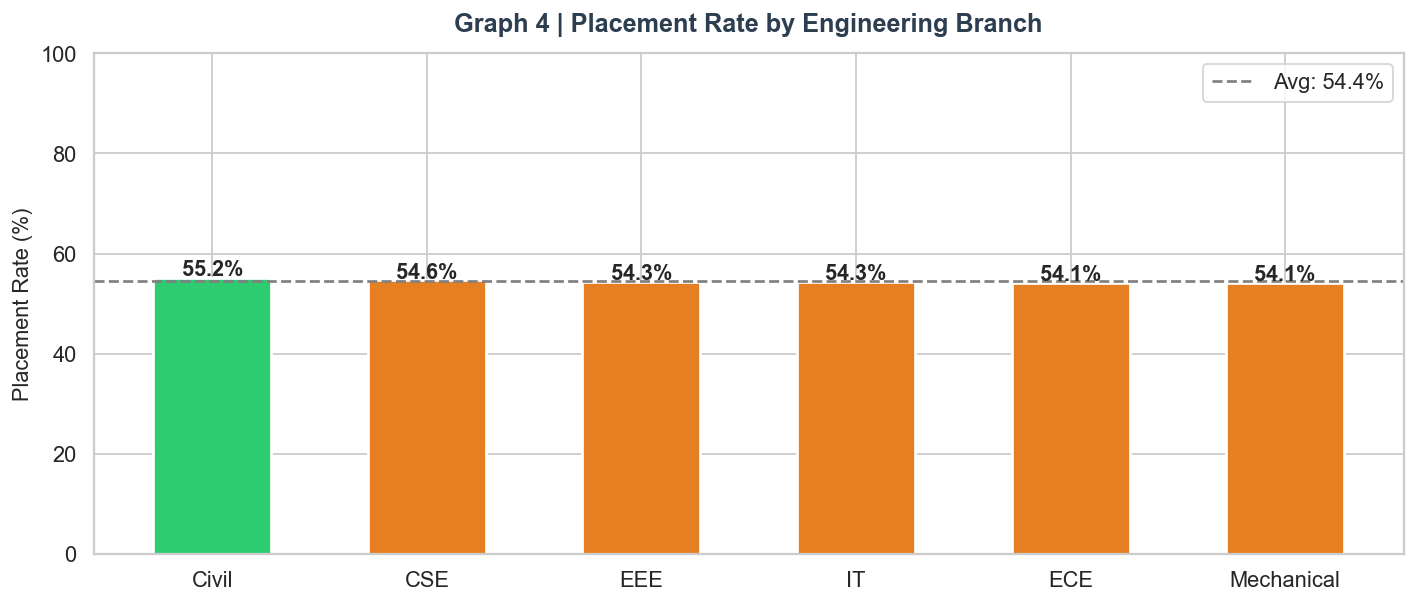

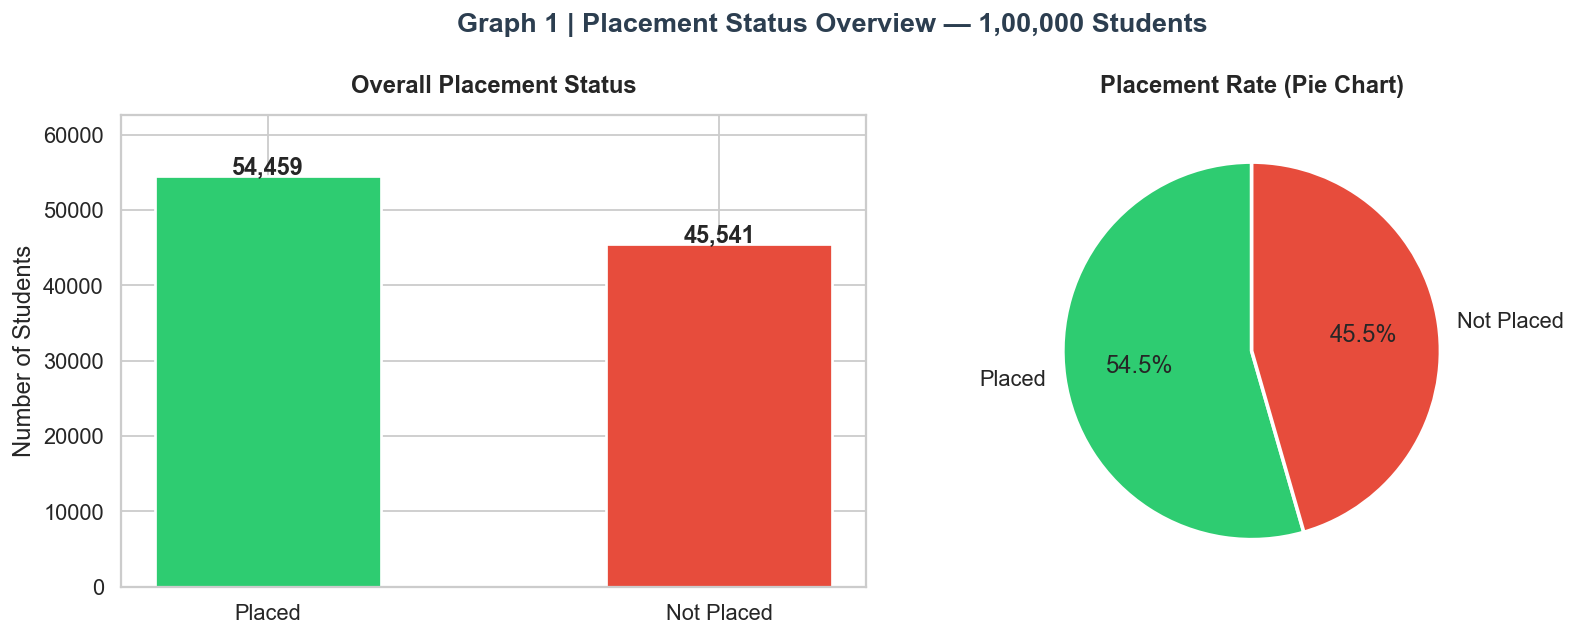

In [26]:
print("\n[EDA] Generating Category 1: Placement Overview")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df_clean["placement_status"].value_counts()

axes[0].bar(counts.index, counts.values,
            color=[PALETTE[k] for k in counts.index],
            edgecolor="white", linewidth=1.5, width=0.5)

for i, (k, v) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, v + 300, f"{v:,}", ha="center",
                 fontweight="bold", fontsize=13)

axes[0].set_title("Overall Placement Status", fontweight="bold")
axes[0].set_ylabel("Number of Students")
axes[0].set_ylim(0, counts.max() * 1.15)

axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=[PALETTE[k] for k in counts.index],
            startangle=90,
            wedgeprops={"edgecolor":"white","linewidth":2})

axes[1].set_title("Placement Rate (Pie Chart)", fontweight="bold")

fig.suptitle("Graph 1 | Placement Status Overview — 1,00,000 Students",
             fontsize=15, fontweight="bold", color=C_DARK)

plt.xticks(rotation=20)
savefig("01_placement_overview")

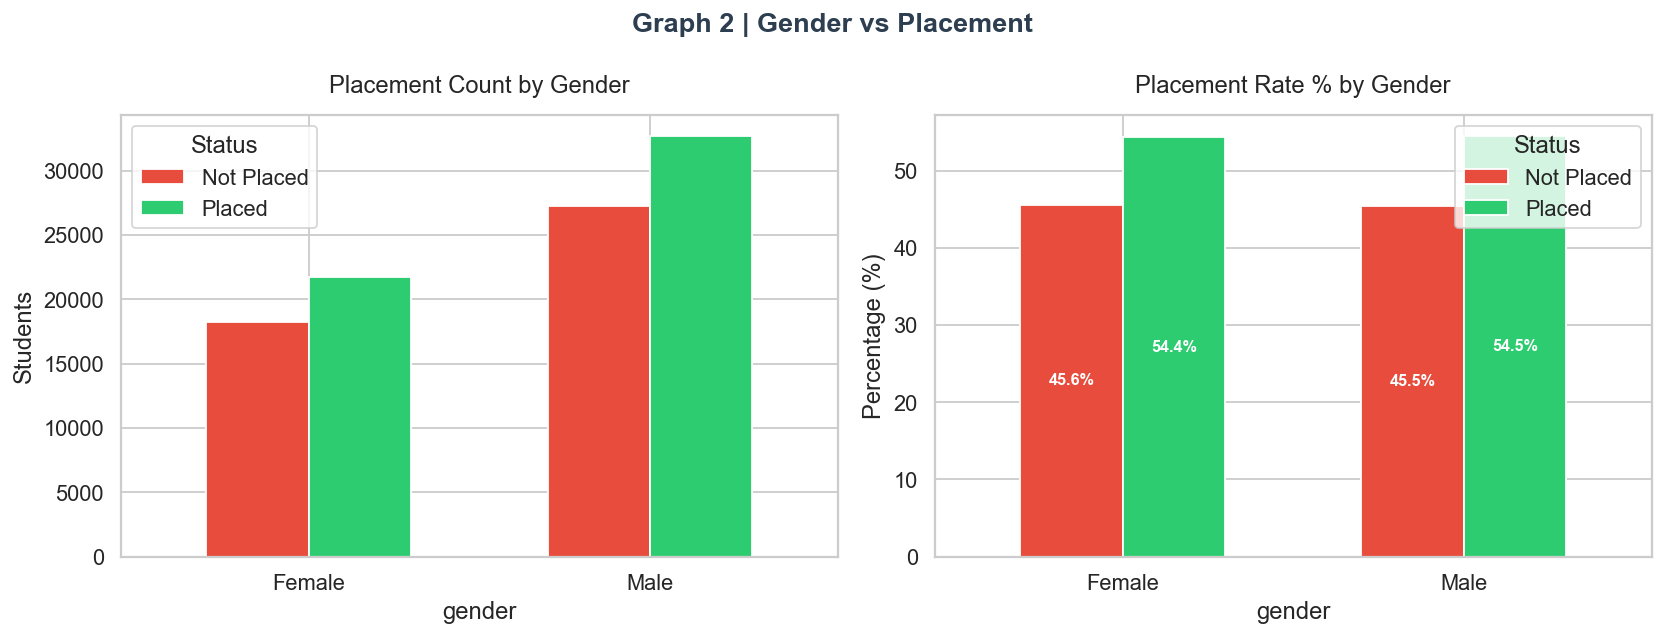

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cross = pd.crosstab(df_clean["gender"], df_clean["placement_status"])
cross.plot(kind="bar", ax=axes[0], color=[C_RED, C_GREEN], edgecolor="white",
           width=0.6, rot=0)
axes[0].set_title("Placement Count by Gender")
axes[0].set_ylabel("Students"); axes[0].legend(title="Status")

cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
cross_pct.plot(kind="bar", ax=axes[1], color=[C_RED, C_GREEN],
               edgecolor="white", width=0.6, rot=0)
axes[1].set_title("Placement Rate % by Gender")
axes[1].set_ylabel("Percentage (%)"); axes[1].legend(title="Status")
for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.1f%%", label_type="center", fontsize=9, color="white", fontweight="bold")
fig.suptitle("Graph 2 | Gender vs Placement", fontsize=15, fontweight="bold", color=C_DARK)
savefig("02_gender_placement")

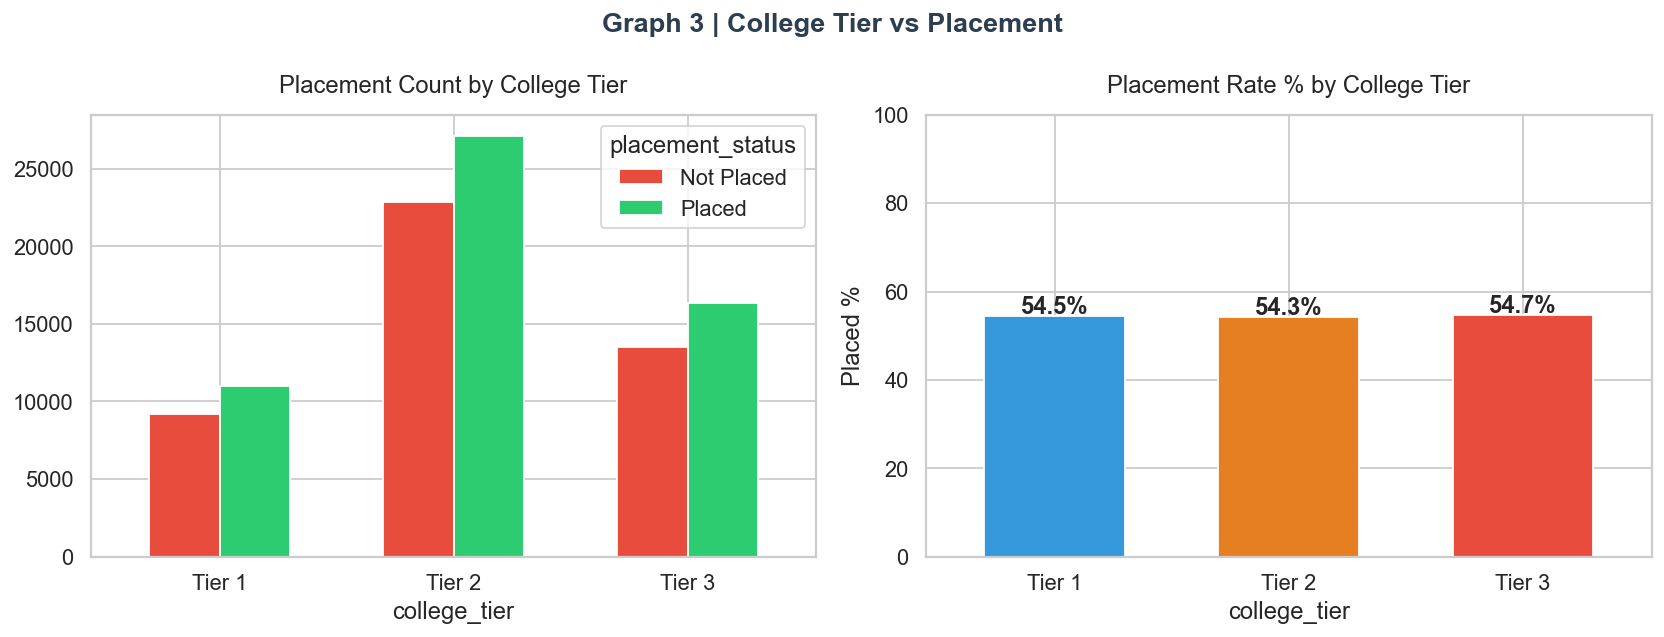

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
tier_order = ["Tier 1", "Tier 2", "Tier 3"]
cross_t = pd.crosstab(df_clean["college_tier"], df_clean["placement_status"]).reindex(tier_order)
cross_t.plot(kind="bar", ax=axes[0], color=[C_RED, C_GREEN], edgecolor="white", rot=0, width=0.6)
axes[0].set_title("Placement Count by College Tier")
cross_tp = cross_t.div(cross_t.sum(axis=1), axis=0) * 100
cross_tp["Placed"].plot(kind="bar", ax=axes[1],
                        color=[C_BLUE, C_ORANGE, C_RED], edgecolor="white", rot=0, width=0.6)
for i, v in enumerate(cross_tp["Placed"]):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")
axes[1].set_title("Placement Rate % by College Tier")
axes[1].set_ylabel("Placed %"); axes[1].set_ylim(0, 100)
fig.suptitle("Graph 3 | College Tier vs Placement", fontsize=15, fontweight="bold", color=C_DARK)
savefig("03_tier_placement")

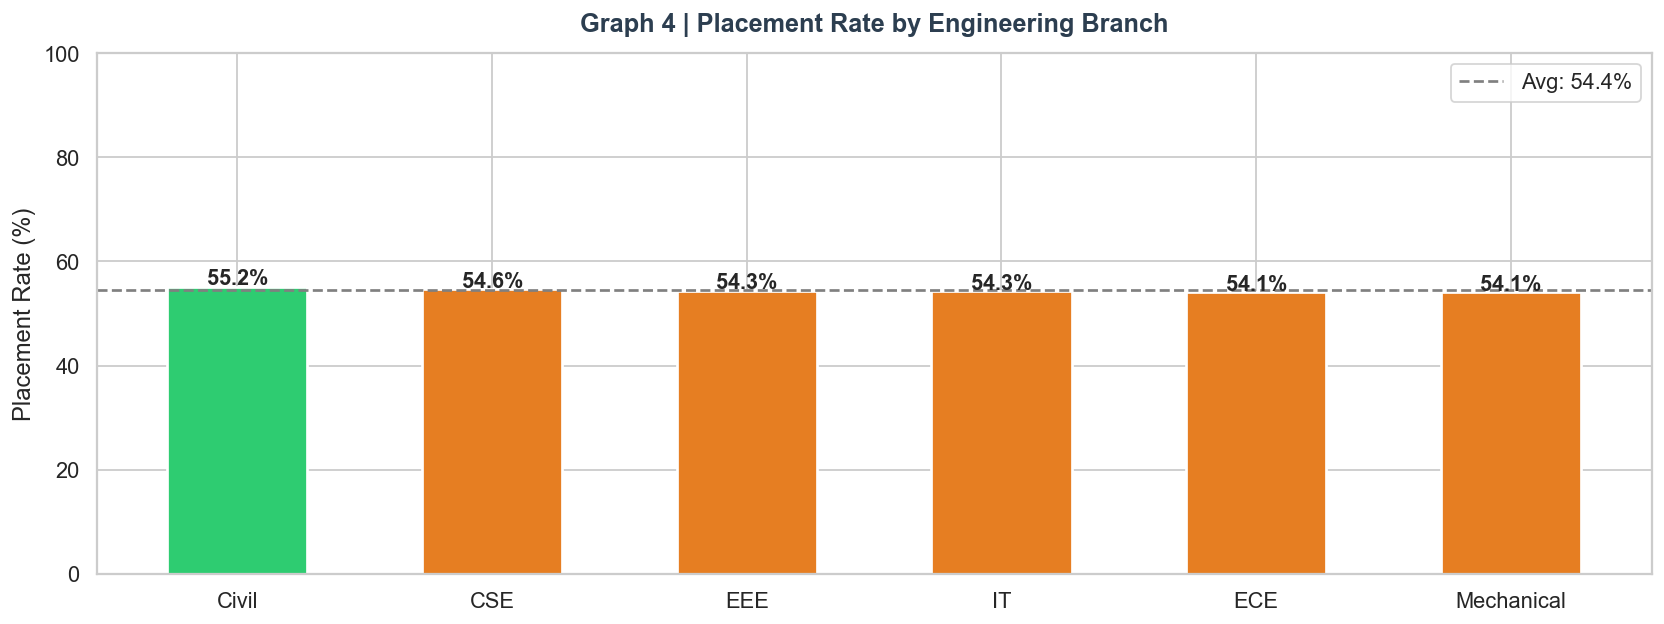

In [29]:
fig, ax = plt.subplots(figsize=(13, 5))
branch_rate = (df_clean.groupby("branch")["target"].mean() * 100).sort_values(ascending=False)
colors = [C_GREEN if v >= 55 else C_ORANGE if v >= 45 else C_RED for v in branch_rate.values]
bars = ax.bar(branch_rate.index, branch_rate.values, color=colors, edgecolor="white", linewidth=1.5, width=0.55)
for bar, val in zip(bars, branch_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f"{val:.1f}%", ha="center", fontweight="bold", fontsize=12)
ax.set_ylabel("Placement Rate (%)"); ax.set_ylim(0, 100)
ax.set_title("Graph 4 | Placement Rate by Engineering Branch", fontsize=14, fontweight="bold", color=C_DARK)
ax.axhline(branch_rate.mean(), color="grey", linestyle="--", linewidth=1.5, label=f"Avg: {branch_rate.mean():.1f}%")
ax.legend()
savefig("04_branch_placement")

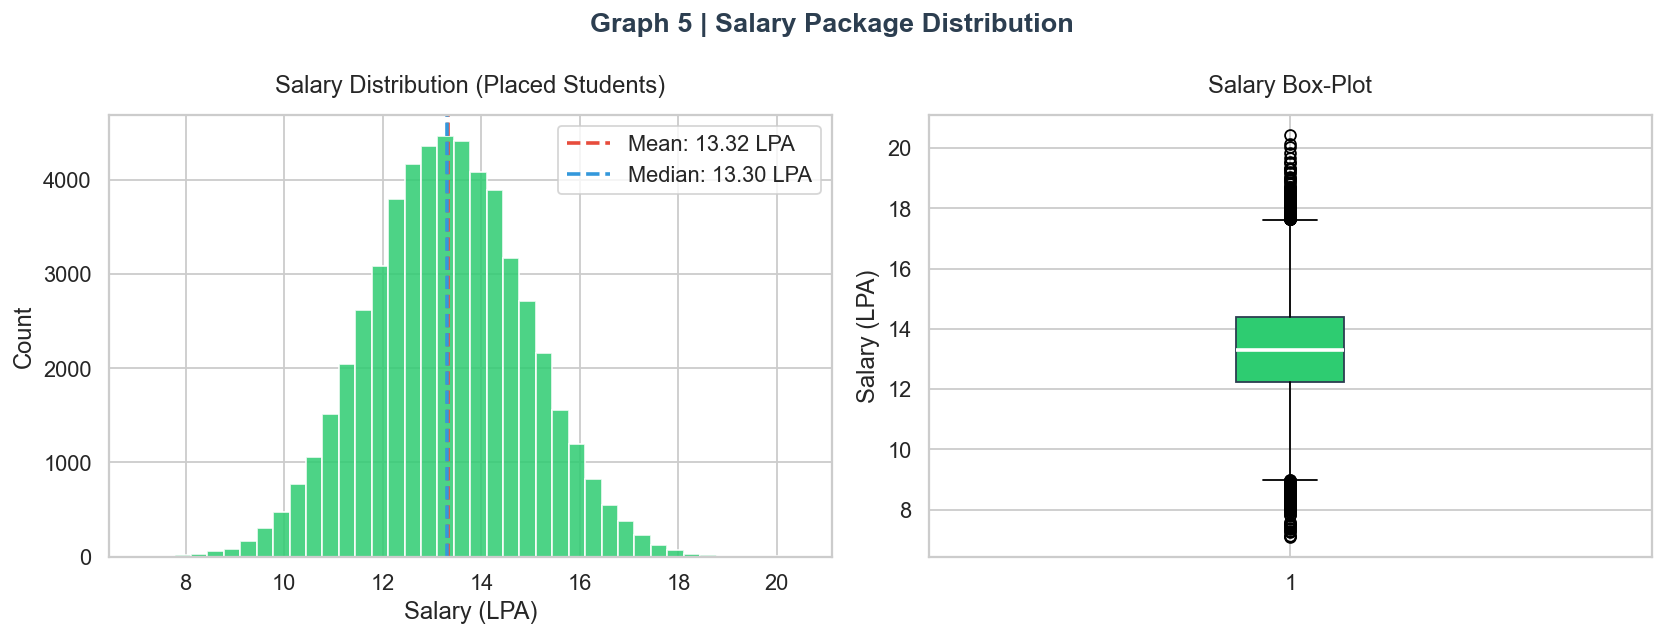

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sal = df_clean[df_clean["placement_status"] == "Placed"]["salary_package_lpa"]
axes[0].hist(sal, bins=40, color=C_GREEN, edgecolor="white", alpha=0.85)
axes[0].axvline(sal.mean(), color=C_RED, linestyle="--", linewidth=2, label=f"Mean: {sal.mean():.2f} LPA")
axes[0].axvline(sal.median(), color=C_BLUE, linestyle="--", linewidth=2, label=f"Median: {sal.median():.2f} LPA")
axes[0].set_title("Salary Distribution (Placed Students)"); axes[0].legend()
axes[0].set_xlabel("Salary (LPA)"); axes[0].set_ylabel("Count")
axes[1].boxplot(sal, patch_artist=True,
                boxprops=dict(facecolor=C_GREEN, color=C_DARK),
                medianprops=dict(color="white", linewidth=2))
axes[1].set_title("Salary Box-Plot"); axes[1].set_ylabel("Salary (LPA)")
fig.suptitle("Graph 5 | Salary Package Distribution", fontsize=15, fontweight="bold", color=C_DARK)
savefig("05_salary_distribution")

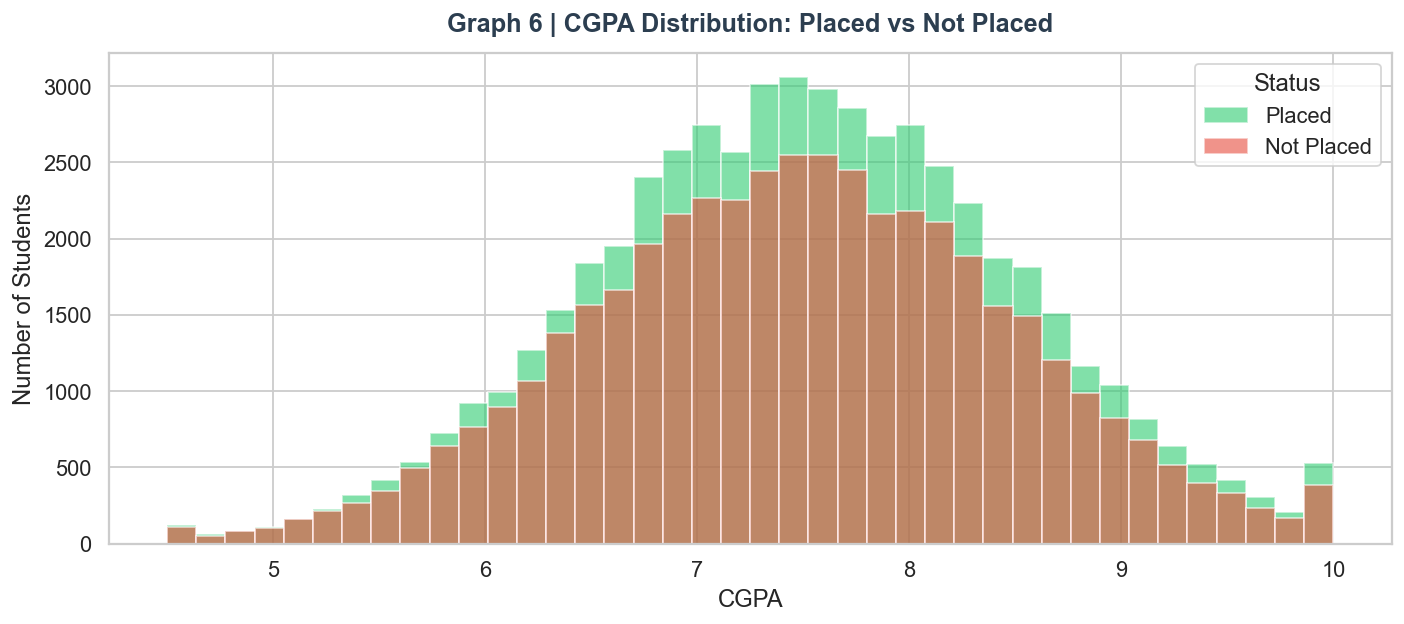

In [31]:
fig, ax = plt.subplots(figsize=(11, 5))
for status, color in [("Placed", C_GREEN), ("Not Placed", C_RED)]:
    data = df_clean[df_clean["placement_status"] == status]["cgpa"]
    ax.hist(data, bins=40, alpha=0.6, color=color, label=status, edgecolor="white")
ax.set_xlabel("CGPA"); ax.set_ylabel("Number of Students")
ax.set_title("Graph 6 | CGPA Distribution: Placed vs Not Placed", fontsize=14, fontweight="bold", color=C_DARK)
ax.legend(title="Status")
savefig("06_cgpa_distribution")

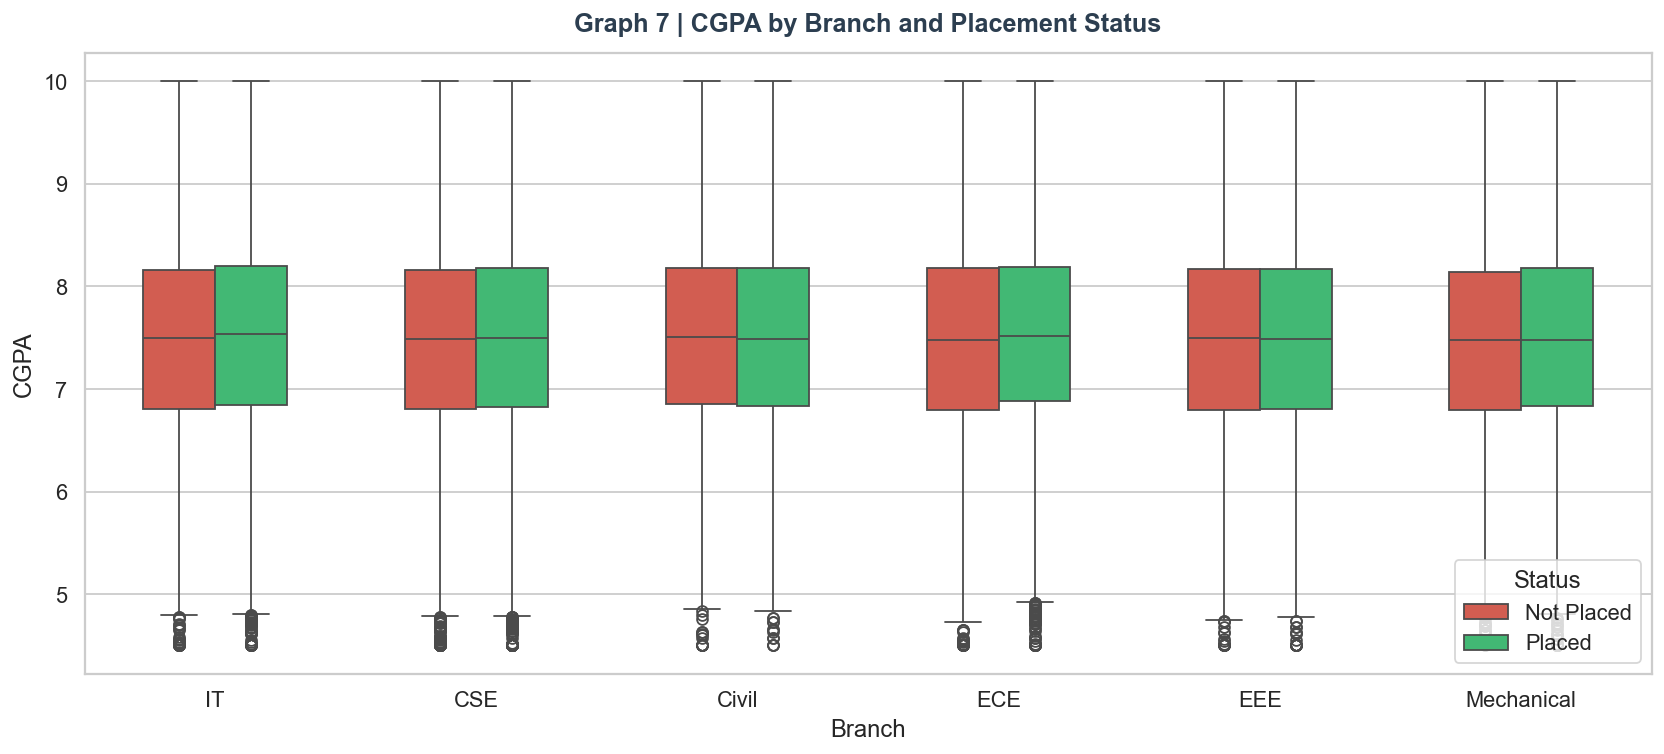

In [32]:
fig, ax = plt.subplots(figsize=(13, 6))
branch_order = df_clean.groupby("branch")["cgpa"].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x="branch", y="cgpa", hue="placement_status",
            order=branch_order, palette=PALETTE, ax=ax, width=0.55)
ax.set_title("Graph 7 | CGPA by Branch and Placement Status", fontsize=14, fontweight="bold", color=C_DARK)
ax.set_xlabel("Branch"); ax.set_ylabel("CGPA")
ax.legend(title="Status", loc="lower right")
savefig("07_cgpa_branch_boxplot")

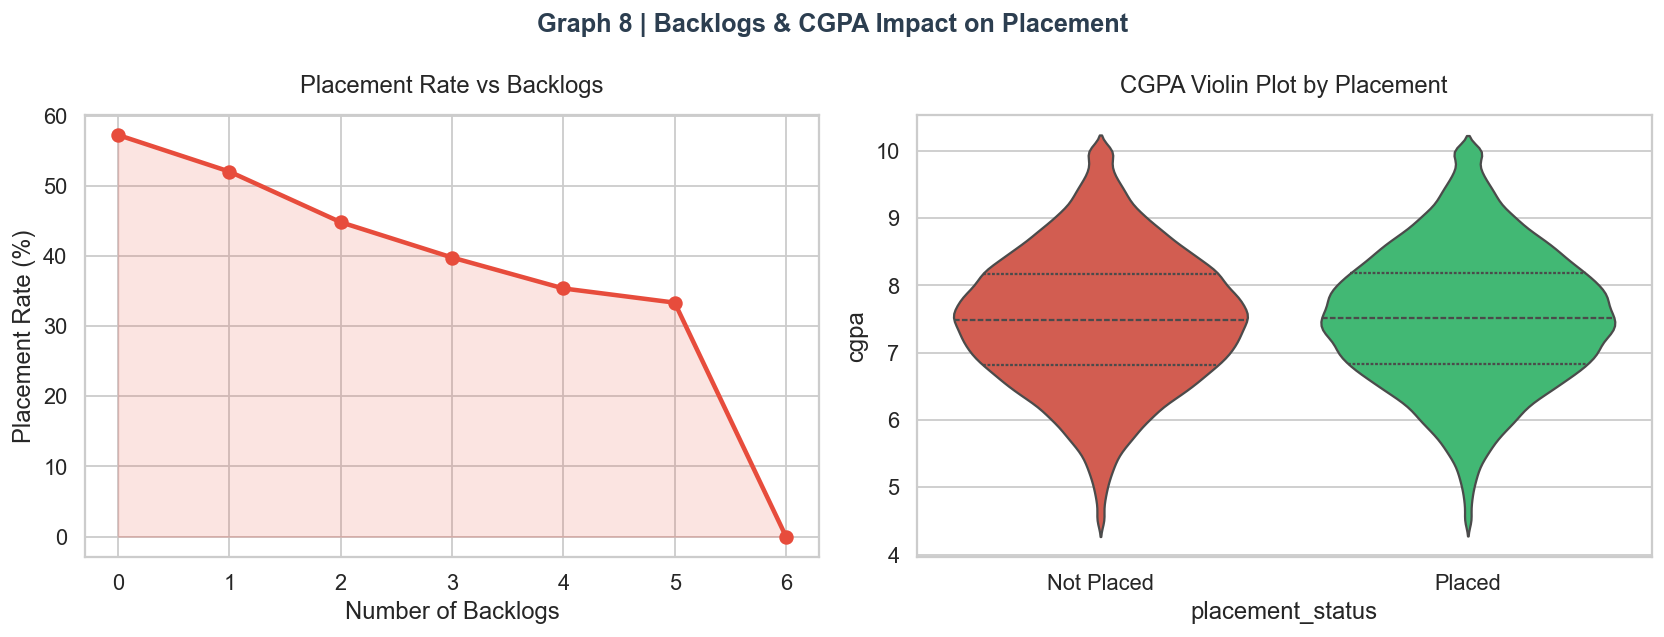

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
backlog_rate = df_clean.groupby("backlogs")["target"].mean() * 100
axes[0].plot(backlog_rate.index, backlog_rate.values, marker="o", color=C_RED, linewidth=2.5, markersize=7)
axes[0].fill_between(backlog_rate.index, backlog_rate.values, alpha=0.15, color=C_RED)
axes[0].set_xlabel("Number of Backlogs"); axes[0].set_ylabel("Placement Rate (%)")
axes[0].set_title("Placement Rate vs Backlogs")
sns.violinplot(data=df_clean, x="placement_status", y="cgpa",
               palette=PALETTE, ax=axes[1], inner="quartile")
axes[1].set_title("CGPA Violin Plot by Placement")
fig.suptitle("Graph 8 | Backlogs & CGPA Impact on Placement", fontsize=14, fontweight="bold", color=C_DARK)
savefig("08_backlogs_cgpa")

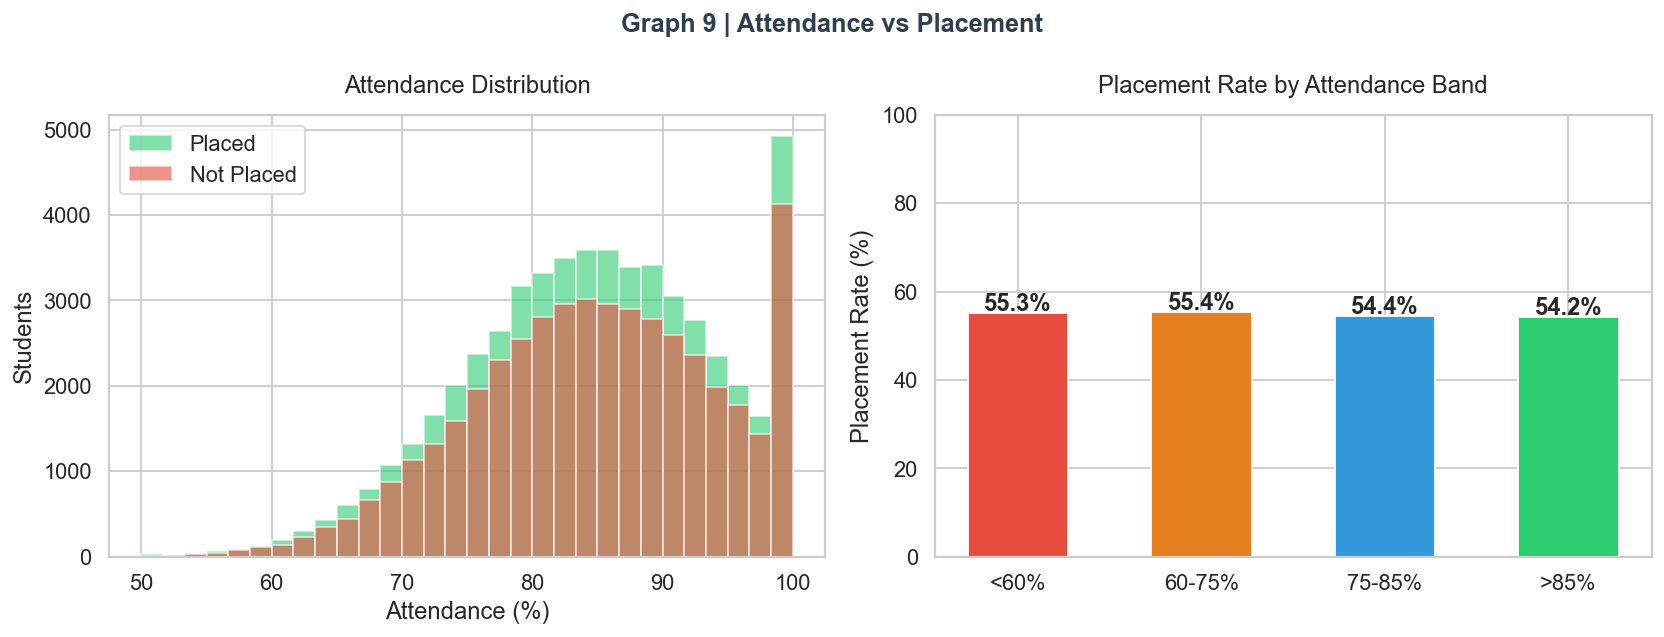

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for status, color in [("Placed", C_GREEN), ("Not Placed", C_RED)]:
    data = df_clean[df_clean["placement_status"] == status]["attendance_percentage"]
    axes[0].hist(data, bins=30, alpha=0.6, color=color, label=status, edgecolor="white")
axes[0].set_xlabel("Attendance (%)"); axes[0].set_ylabel("Students")
axes[0].set_title("Attendance Distribution")
axes[0].legend()

att_bins = pd.cut(df_clean["attendance_percentage"], bins=[0,60,75,85,100],
                  labels=["<60%","60-75%","75-85%",">85%"])
att_rate = df_clean.groupby(att_bins, observed=True)["target"].mean() * 100
axes[1].bar(att_rate.index.astype(str), att_rate.values,
            color=[C_RED, C_ORANGE, C_BLUE, C_GREEN], edgecolor="white", width=0.55)
for i, v in enumerate(att_rate.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")
axes[1].set_ylabel("Placement Rate (%)"); axes[1].set_ylim(0, 100)
axes[1].set_title("Placement Rate by Attendance Band")
fig.suptitle("Graph 9 | Attendance vs Placement", fontsize=14, fontweight="bold", color=C_DARK)
savefig("09_attendance_placement")

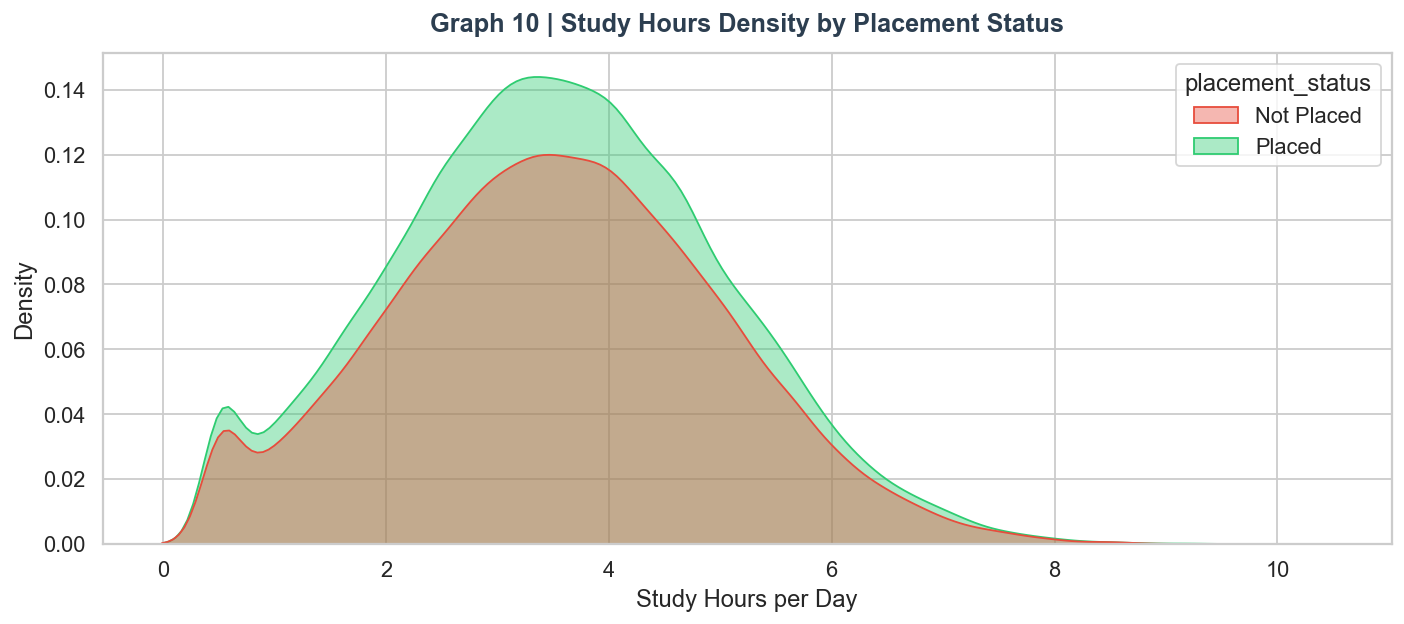

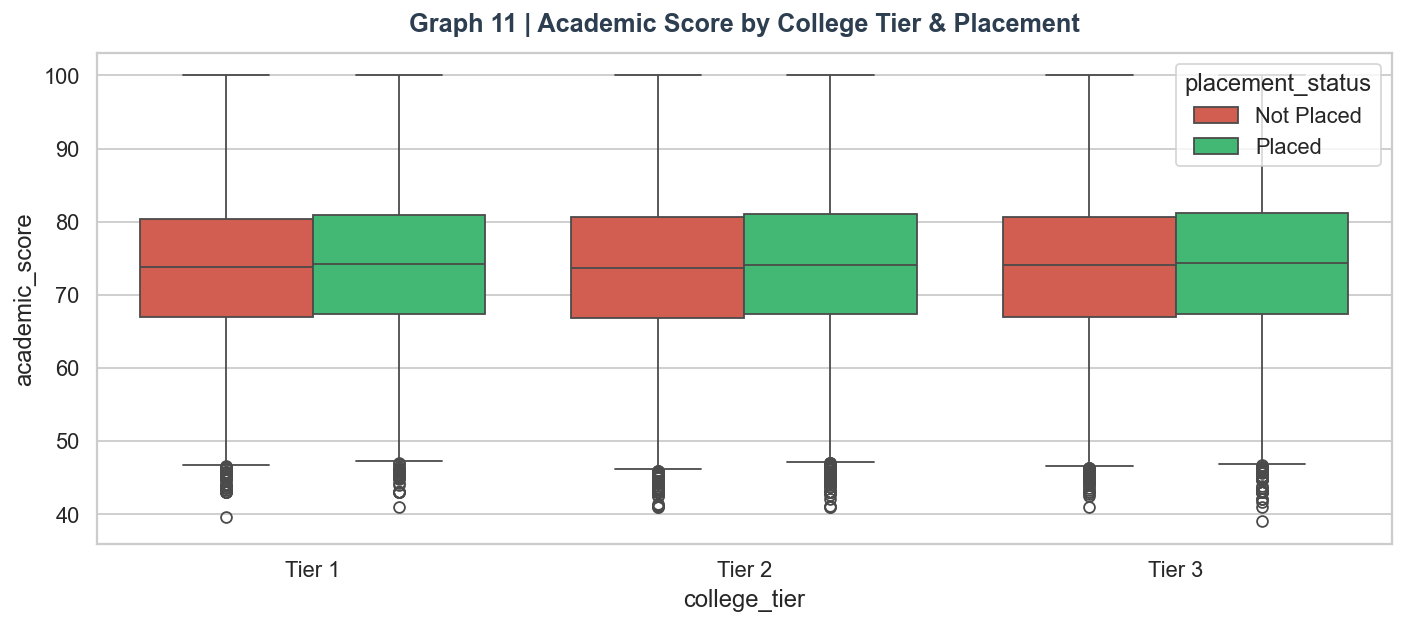

In [35]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.kdeplot(data=df_clean, x="study_hours_per_day", hue="placement_status",
            palette=PALETTE, fill=True, alpha=0.4, ax=ax)
ax.set_xlabel("Study Hours per Day"); ax.set_ylabel("Density")
ax.set_title("Graph 10 | Study Hours Density by Placement Status", fontsize=14, fontweight="bold", color=C_DARK)
savefig("10_study_hours")

# Graph 11: Academic Score (composite) by College Tier
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df_clean, x="college_tier", y="academic_score",
            order=["Tier 1","Tier 2","Tier 3"],
            hue="placement_status", palette=PALETTE, ax=ax)
ax.set_title("Graph 11 | Academic Score by College Tier & Placement", fontsize=14, fontweight="bold", color=C_DARK)
savefig("11_academic_score_tier")

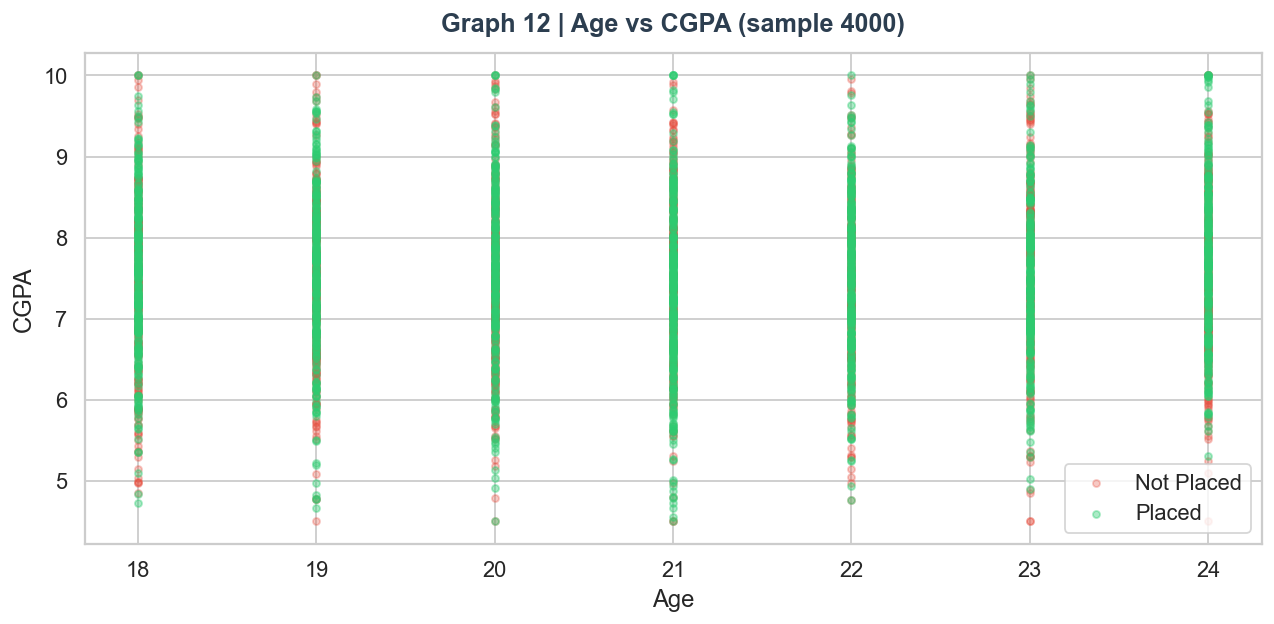

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
for status, color, alpha in [("Not Placed", C_RED, 0.3), ("Placed", C_GREEN, 0.4)]:
    sub = df_clean[df_clean["placement_status"] == status].sample(2000, random_state=42)
    ax.scatter(sub["age"], sub["cgpa"], c=color, alpha=alpha, s=15, label=status)
ax.set_xlabel("Age"); ax.set_ylabel("CGPA")
ax.set_title("Graph 12 | Age vs CGPA (sample 4000)", fontsize=14, fontweight="bold", color=C_DARK)
ax.legend()
savefig("12_age_cgpa_scatter")

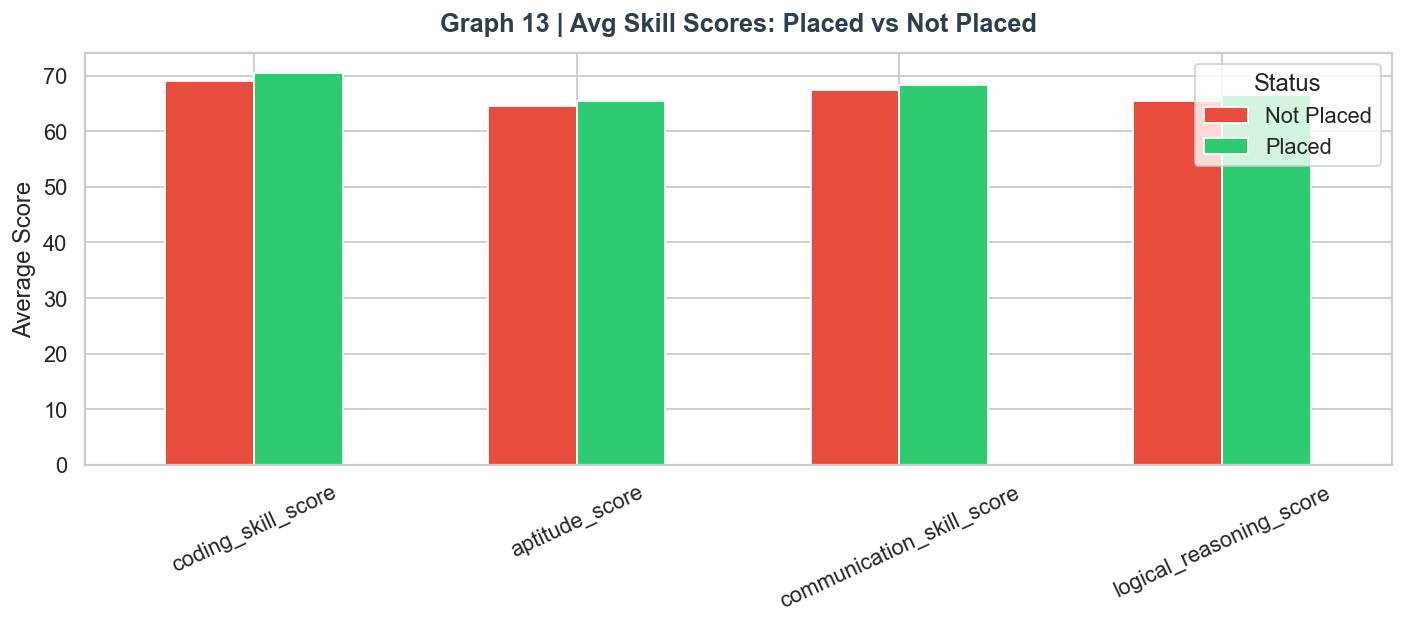

In [38]:
#  DEFINE THIS FIRST
skill_cols = [
    "coding_skill_score",
    "aptitude_score",
    "communication_skill_score",
    "logical_reasoning_score"
]

# GRAPH
fig, ax = plt.subplots(figsize=(11, 5))

skill_avg = df_clean.groupby("placement_status")[skill_cols].mean()

skill_avg.T.plot(kind="bar",
                 ax=ax,
                 color=[C_RED, C_GREEN],
                 edgecolor="white",
                 rot=30,
                 width=0.55)

ax.set_ylabel("Average Score")

ax.set_title("Graph 13 | Avg Skill Scores: Placed vs Not Placed",
             fontsize=14, fontweight="bold", color=C_DARK)

ax.legend(title="Status")

plt.xticks(rotation=25)
savefig("13_skill_avg_comparison")

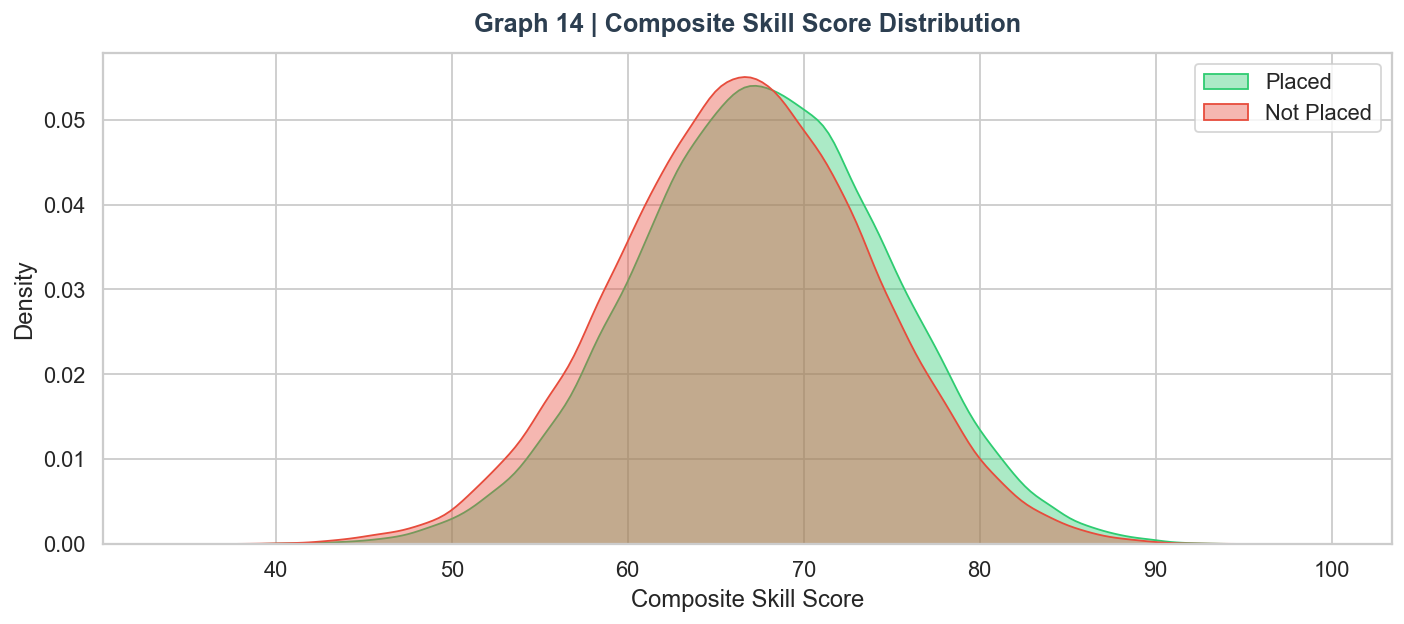

In [39]:
fig, ax = plt.subplots(figsize=(11, 5))
for status, color in [("Placed", C_GREEN), ("Not Placed", C_RED)]:
    sns.kdeplot(df_clean[df_clean["placement_status"] == status]["skill_composite"],
                ax=ax, color=color, fill=True, alpha=0.4, label=status)
ax.set_xlabel("Composite Skill Score"); ax.set_ylabel("Density")
ax.set_title("Graph 14 | Composite Skill Score Distribution", fontsize=14, fontweight="bold", color=C_DARK)
ax.legend()
savefig("14_skill_composite_kde")

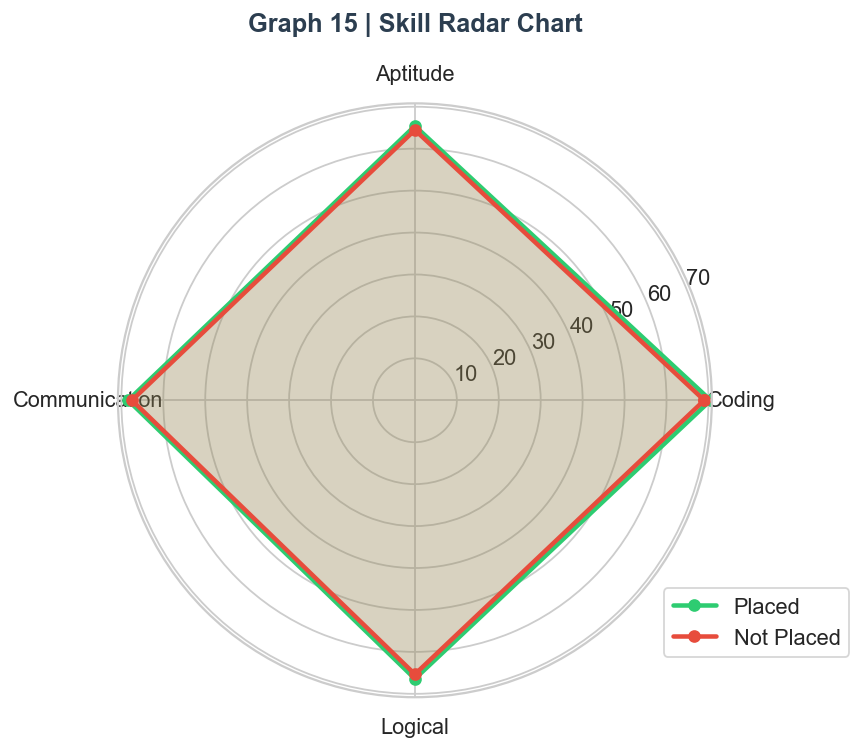

In [40]:
categories = ["Coding", "Aptitude", "Communication", "Logical"]
placed_avg    = df_clean[df_clean["placement_status"]=="Placed"][skill_cols].mean().values
notplaced_avg = df_clean[df_clean["placement_status"]=="Not Placed"][skill_cols].mean().values
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]
placed_avg    = list(placed_avg) + [placed_avg[0]]
notplaced_avg = list(notplaced_avg) + [notplaced_avg[0]]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True})
ax.plot(angles, placed_avg, "o-", color=C_GREEN, linewidth=2.5, label="Placed")
ax.fill(angles, placed_avg, alpha=0.2, color=C_GREEN)
ax.plot(angles, notplaced_avg, "o-", color=C_RED, linewidth=2.5, label="Not Placed")
ax.fill(angles, notplaced_avg, alpha=0.2, color=C_RED)
ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=12)
ax.set_title("Graph 15 | Skill Radar Chart", fontsize=14, fontweight="bold", color=C_DARK, pad=18)
ax.legend(loc="lower right", bbox_to_anchor=(1.25, 0.05))
savefig("15_skill_radar")

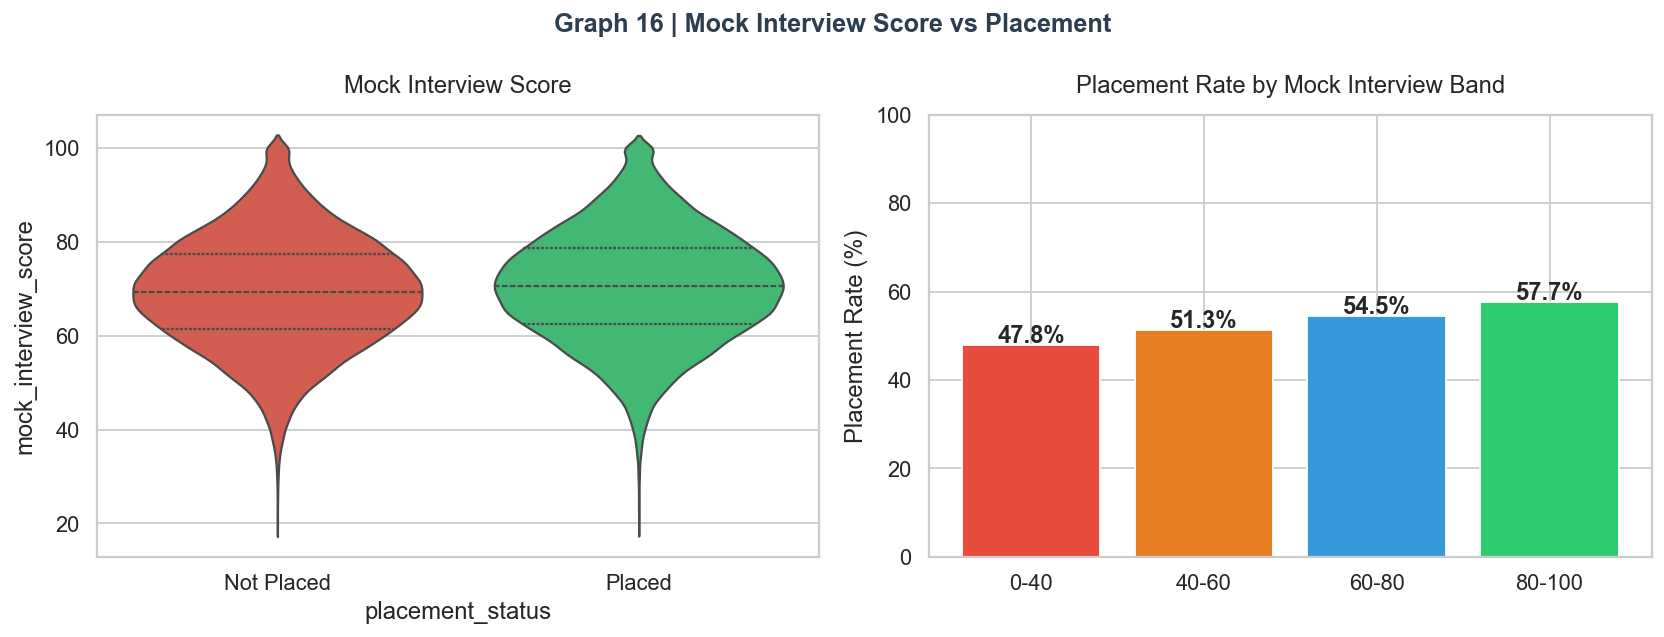

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.violinplot(data=df_clean, x="placement_status", y="mock_interview_score",
               palette=PALETTE, ax=axes[0], inner="quartile")
axes[0].set_title("Mock Interview Score")
mock_bins = pd.cut(df_clean["mock_interview_score"], bins=[0,40,60,80,100],
                   labels=["0-40","40-60","60-80","80-100"])
mock_rate = df_clean.groupby(mock_bins, observed=True)["target"].mean() * 100
axes[1].bar(mock_rate.index.astype(str), mock_rate.values,
            color=[C_RED, C_ORANGE, C_BLUE, C_GREEN], edgecolor="white")
for i, v in enumerate(mock_rate.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")
axes[1].set_ylabel("Placement Rate (%)"); axes[1].set_ylim(0, 100)
axes[1].set_title("Placement Rate by Mock Interview Band")
fig.suptitle("Graph 16 | Mock Interview Score vs Placement", fontsize=14, fontweight="bold", color=C_DARK)
savefig("16_mock_interview")

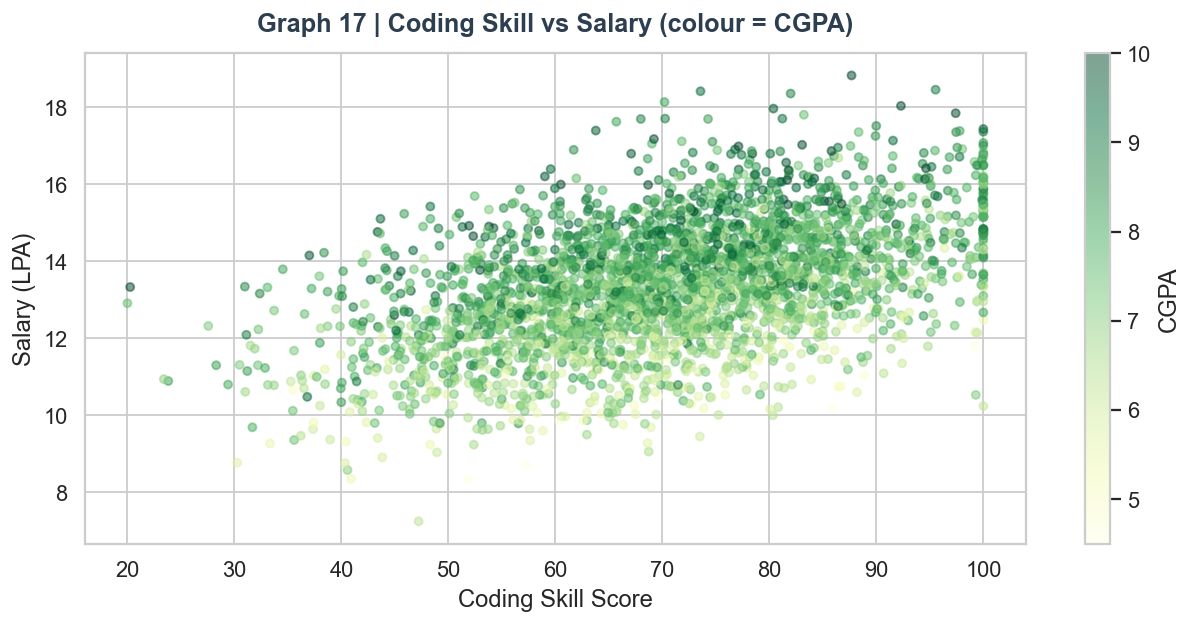

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))
placed = df_clean[df_clean["placement_status"]=="Placed"].sample(3000, random_state=1)
sc = ax.scatter(placed["coding_skill_score"], placed["salary_package_lpa"],
                c=placed["cgpa"], cmap="YlGn", alpha=0.5, s=20)
plt.colorbar(sc, ax=ax, label="CGPA")
ax.set_xlabel("Coding Skill Score"); ax.set_ylabel("Salary (LPA)")
ax.set_title("Graph 17 | Coding Skill vs Salary (colour = CGPA)", fontsize=14, fontweight="bold", color=C_DARK)
savefig("17_coding_salary_scatter")

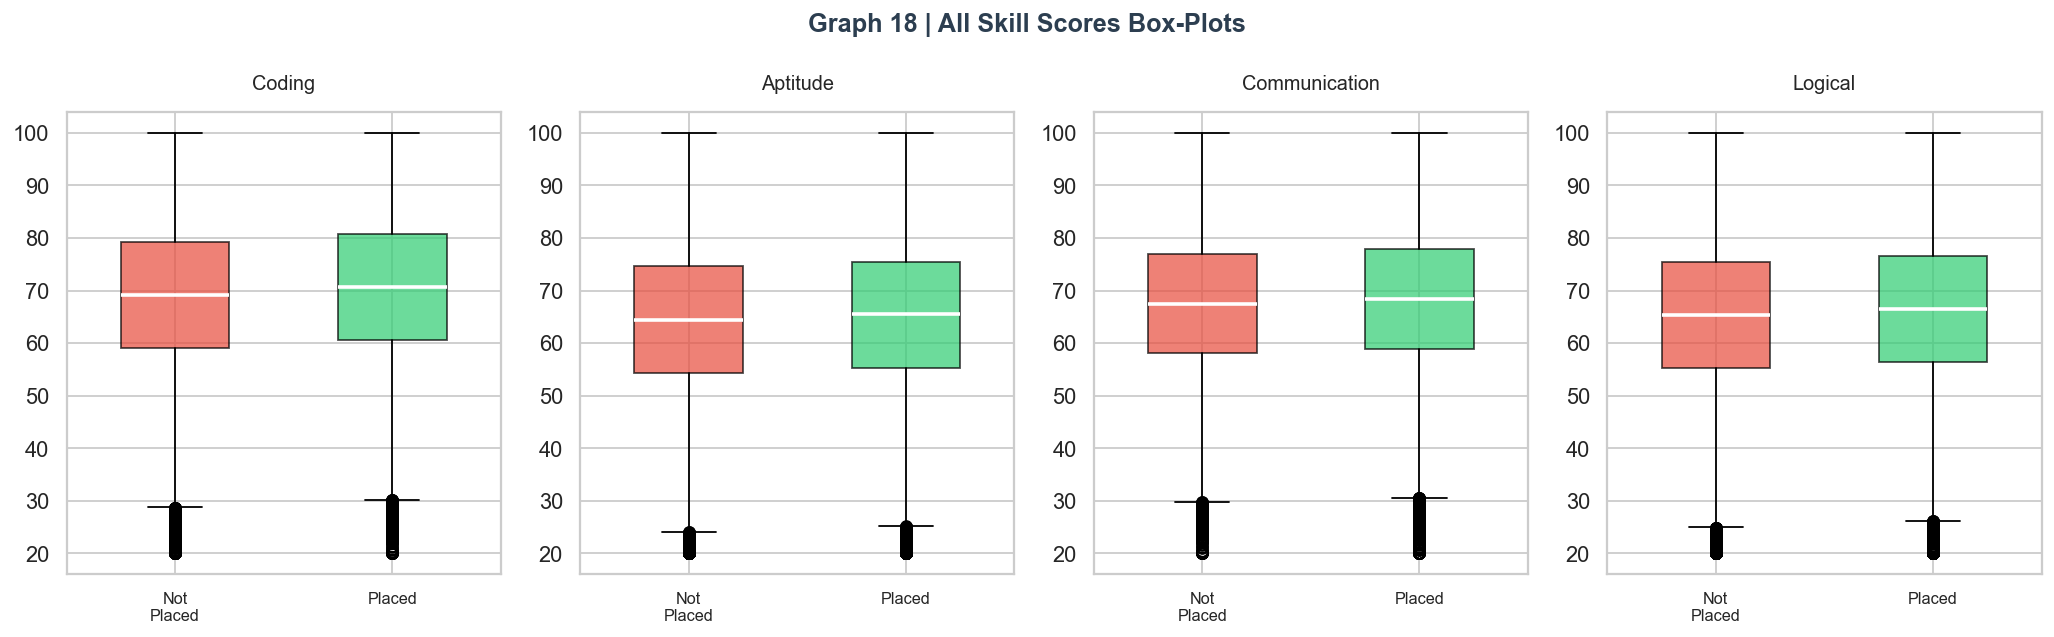

In [43]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
labels_map = {"coding_skill_score":"Coding","aptitude_score":"Aptitude",
              "communication_skill_score":"Communication","logical_reasoning_score":"Logical"}
for ax, col in zip(axes, skill_cols):
    for i, (status, color) in enumerate([("Not Placed", C_RED), ("Placed", C_GREEN)]):
        data = df_clean[df_clean["placement_status"]==status][col]
        ax.boxplot(data, positions=[i], patch_artist=True,
                   boxprops=dict(facecolor=color, alpha=0.7),
                   medianprops=dict(color="white", linewidth=2),
                   widths=0.5)
    ax.set_xticks([0,1]); ax.set_xticklabels(["Not\nPlaced","Placed"], fontsize=9)
    ax.set_title(labels_map[col], fontsize=11)
fig.suptitle("Graph 18 | All Skill Scores Box-Plots", fontsize=14, fontweight="bold", color=C_DARK)
savefig("18_all_skills_boxplot")

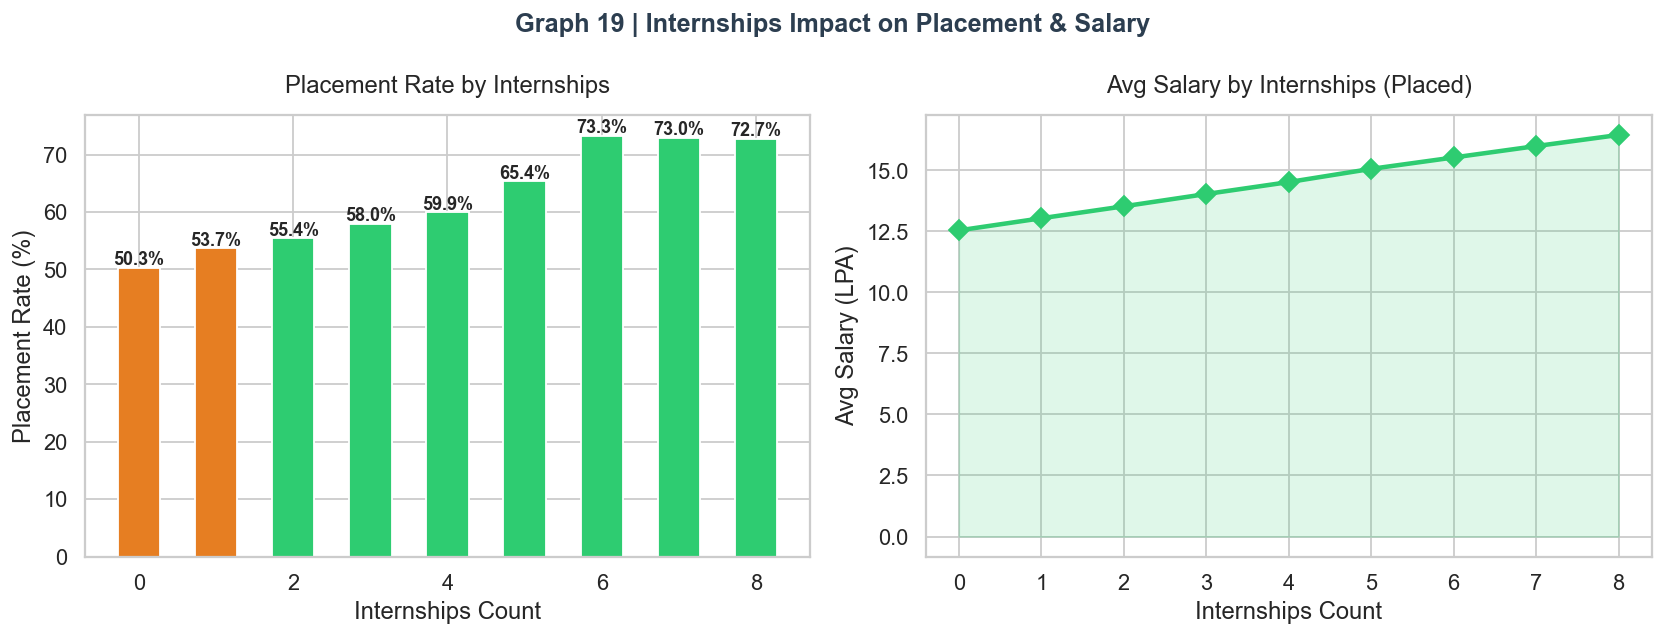

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
intern_rate = df_clean.groupby("internships_count")["target"].mean() * 100
axes[0].bar(intern_rate.index, intern_rate.values,
            color=[C_GREEN if v>=55 else C_ORANGE if v>=45 else C_RED for v in intern_rate.values],
            edgecolor="white", width=0.55)
for i, v in zip(intern_rate.index, intern_rate.values):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold", fontsize=10)
axes[0].set_xlabel("Internships Count"); axes[0].set_ylabel("Placement Rate (%)")
axes[0].set_title("Placement Rate by Internships")
intern_salary = df_clean[df_clean["placement_status"]=="Placed"].groupby("internships_count")["salary_package_lpa"].mean()
axes[1].plot(intern_salary.index, intern_salary.values, marker="D", color=C_GREEN,
             linewidth=2.5, markersize=8)
axes[1].fill_between(intern_salary.index, intern_salary.values, alpha=0.15, color=C_GREEN)
axes[1].set_xlabel("Internships Count"); axes[1].set_ylabel("Avg Salary (LPA)")
axes[1].set_title("Avg Salary by Internships (Placed)")
fig.suptitle("Graph 19 | Internships Impact on Placement & Salary", fontsize=14, fontweight="bold", color=C_DARK)
savefig("19_internships_impact")

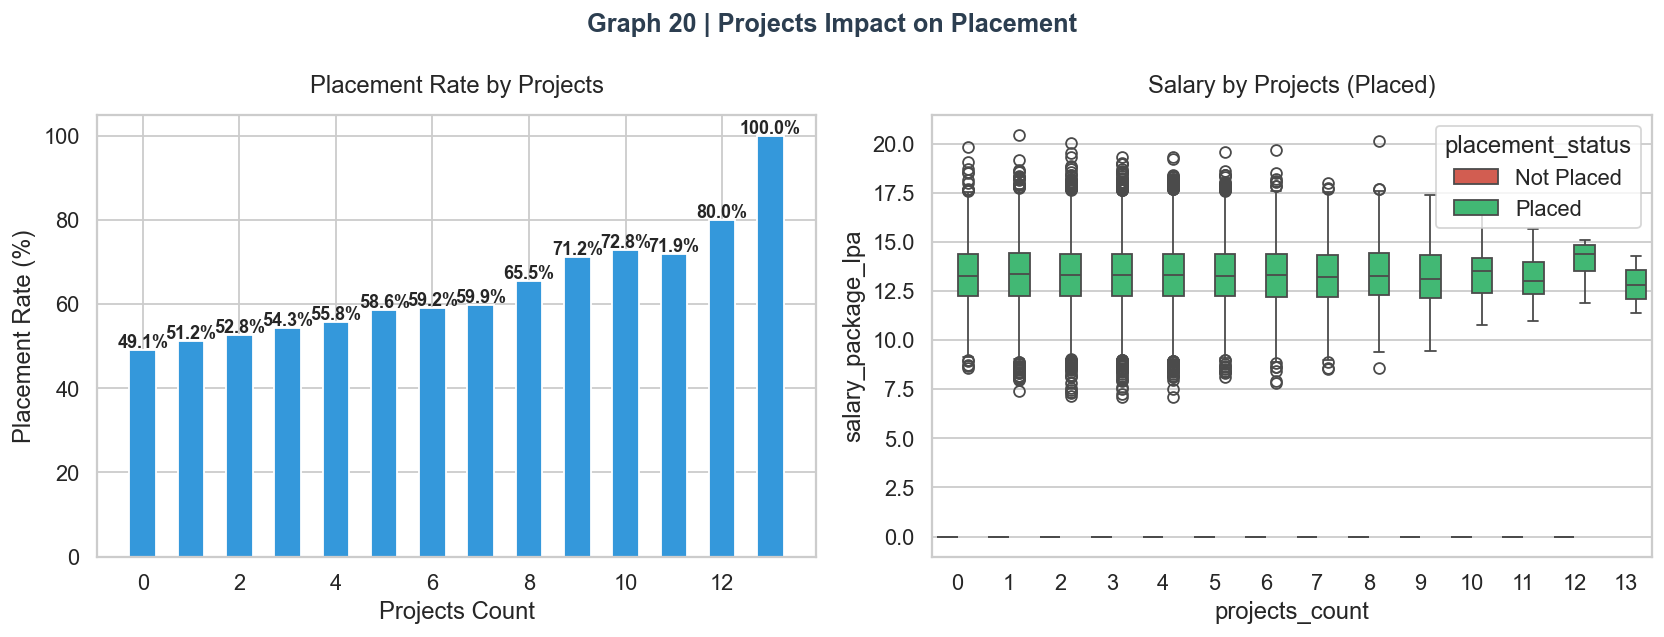

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
proj_rate = df_clean.groupby("projects_count")["target"].mean() * 100
axes[0].bar(proj_rate.index, proj_rate.values, color=C_BLUE, edgecolor="white", width=0.55)
for i, v in zip(proj_rate.index, proj_rate.values):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold", fontsize=10)
axes[0].set_xlabel("Projects Count"); axes[0].set_ylabel("Placement Rate (%)")
axes[0].set_title("Placement Rate by Projects")
sns.boxplot(data=df_clean, x="projects_count", y="salary_package_lpa",
            hue="placement_status", palette=PALETTE, ax=axes[1])
axes[1].set_title("Salary by Projects (Placed)")
fig.suptitle("Graph 20 | Projects Impact on Placement", fontsize=14, fontweight="bold", color=C_DARK)
savefig("20_projects_impact")

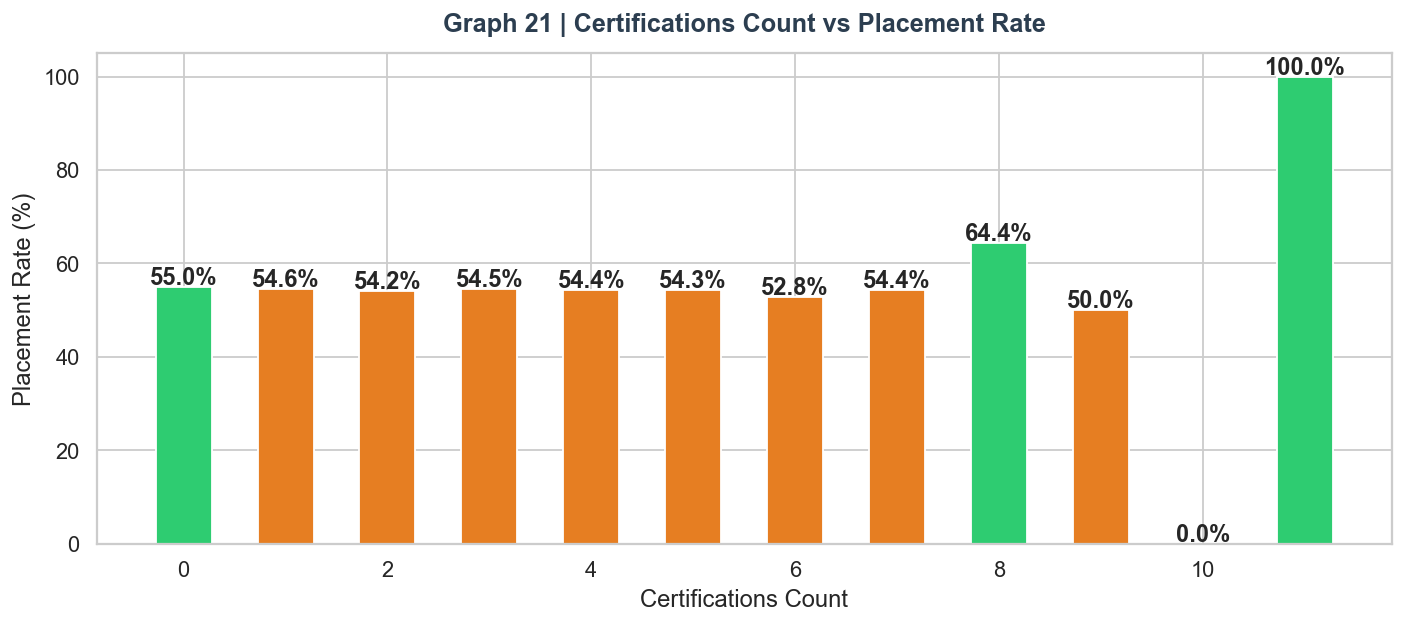

In [46]:
fig, ax = plt.subplots(figsize=(11, 5))
cert_rate = df_clean.groupby("certifications_count")["target"].mean() * 100
ax.bar(cert_rate.index, cert_rate.values,
       color=[C_GREEN if v>=55 else C_ORANGE if v>=45 else C_RED for v in cert_rate.values],
       edgecolor="white", width=0.55)
for i, v in zip(cert_rate.index, cert_rate.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")
ax.set_xlabel("Certifications Count"); ax.set_ylabel("Placement Rate (%)")
ax.set_title("Graph 21 | Certifications Count vs Placement Rate", fontsize=14, fontweight="bold", color=C_DARK)
savefig("21_certifications_placement")

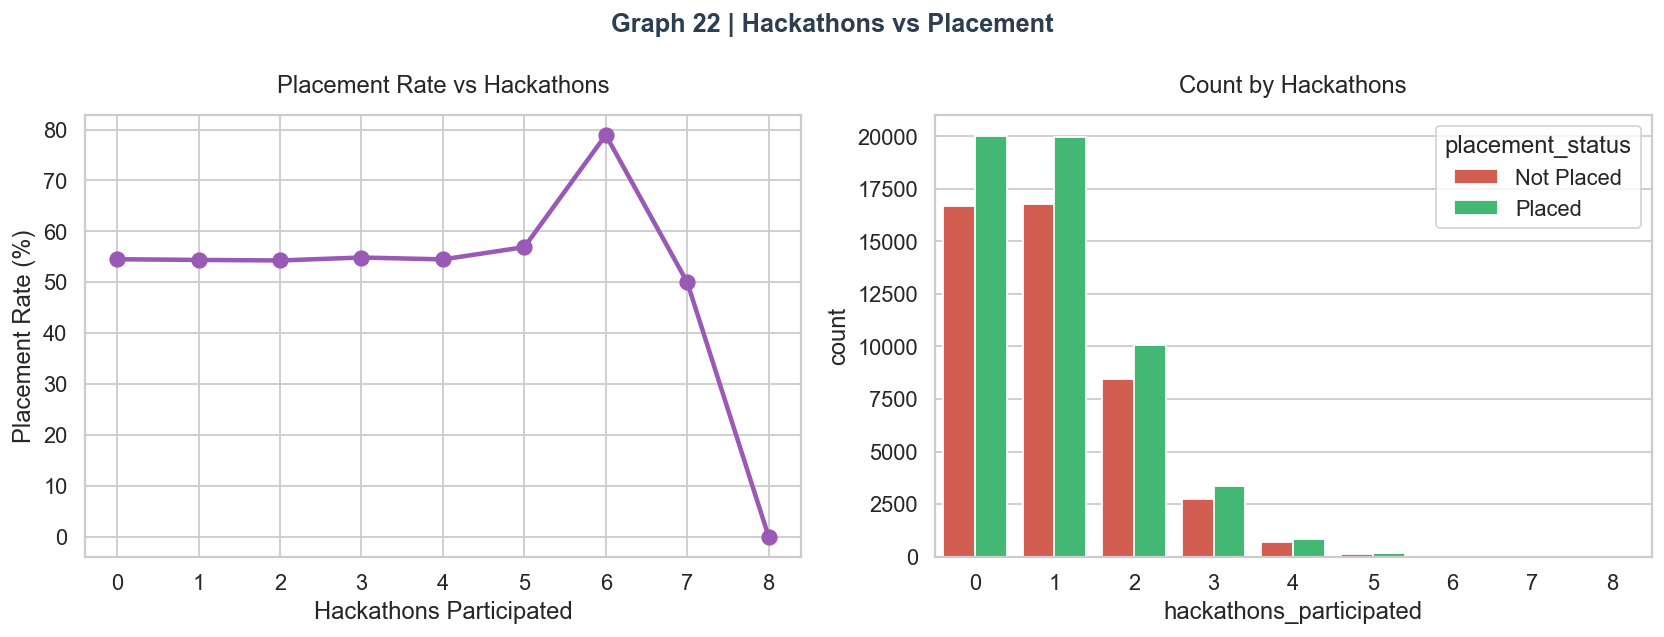

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
hack_rate = df_clean.groupby("hackathons_participated")["target"].mean() * 100
axes[0].plot(hack_rate.index, hack_rate.values, "o-", color=C_PURPLE, linewidth=2.5, markersize=8)
axes[0].set_xlabel("Hackathons Participated"); axes[0].set_ylabel("Placement Rate (%)")
axes[0].set_title("Placement Rate vs Hackathons")
sns.countplot(data=df_clean, x="hackathons_participated",
              hue="placement_status", palette=PALETTE, ax=axes[1])
axes[1].set_title("Count by Hackathons")
fig.suptitle("Graph 22 | Hackathons vs Placement", fontsize=14, fontweight="bold", color=C_DARK)
savefig("22_hackathons_placement")

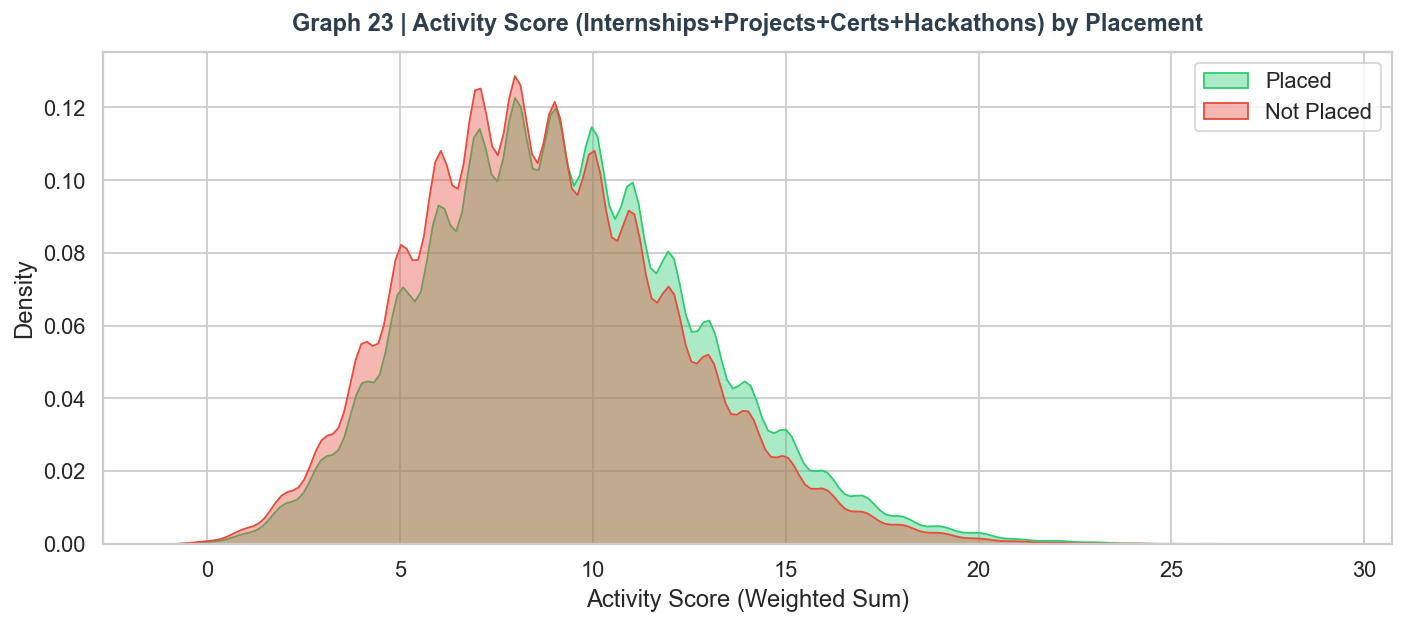

In [48]:
fig, ax = plt.subplots(figsize=(11, 5))
for status, color in [("Placed", C_GREEN), ("Not Placed", C_RED)]:
    sns.kdeplot(df_clean[df_clean["placement_status"]==status]["activity_score"],
                ax=ax, color=color, fill=True, alpha=0.4, label=status)
ax.set_xlabel("Activity Score (Weighted Sum)"); ax.set_ylabel("Density")
ax.set_title("Graph 23 | Activity Score (Internships+Projects+Certs+Hackathons) by Placement",
             fontsize=13, fontweight="bold", color=C_DARK)
ax.legend()
savefig("23_activity_score_kde")

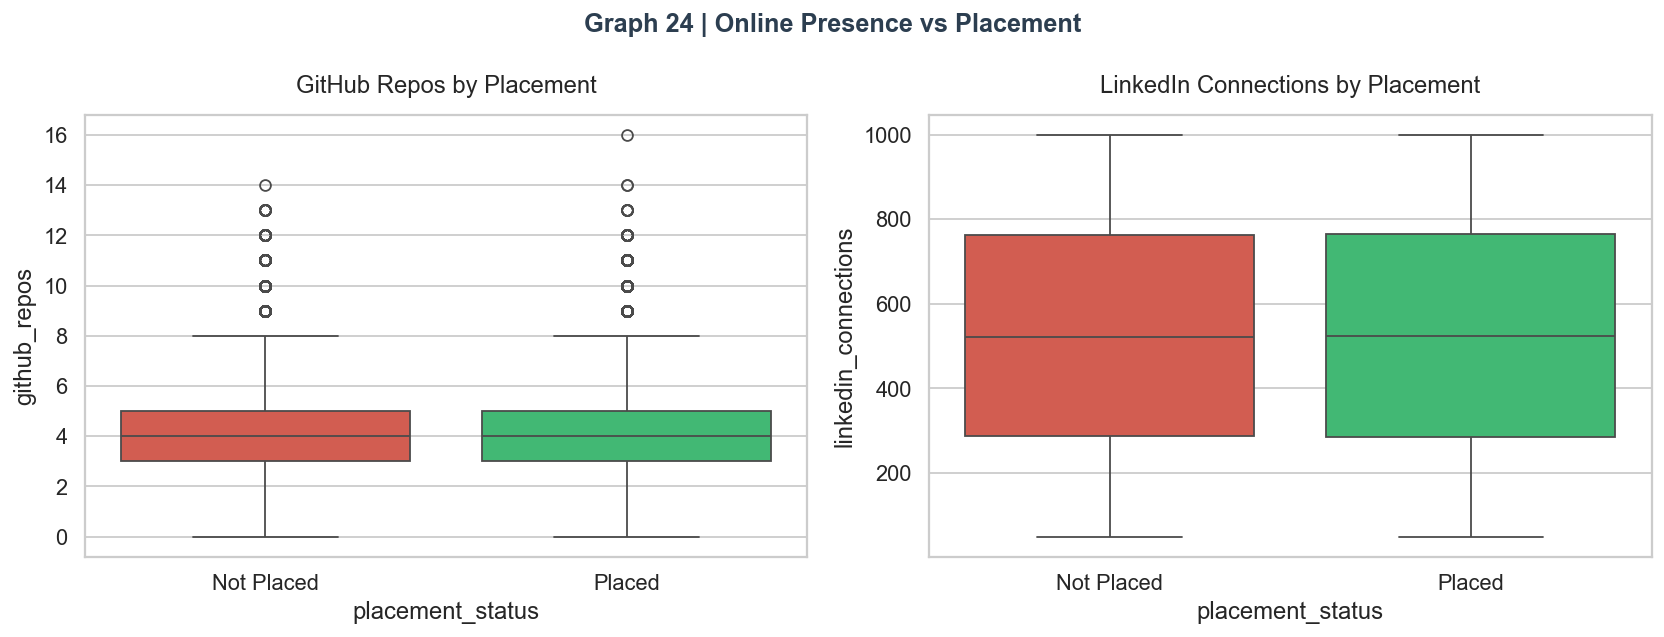

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df_clean, x="placement_status", y="github_repos",
            palette=PALETTE, ax=axes[0])
axes[0].set_title("GitHub Repos by Placement")
sns.boxplot(data=df_clean, x="placement_status", y="linkedin_connections",
            palette=PALETTE, ax=axes[1])
axes[1].set_title("LinkedIn Connections by Placement")
fig.suptitle("Graph 24 | Online Presence vs Placement", fontsize=14, fontweight="bold", color=C_DARK)
savefig("24_online_presence")

In [50]:
print("[EDA] Generating Category 5: Behavioral Factors")

[EDA] Generating Category 5: Behavioral Factors


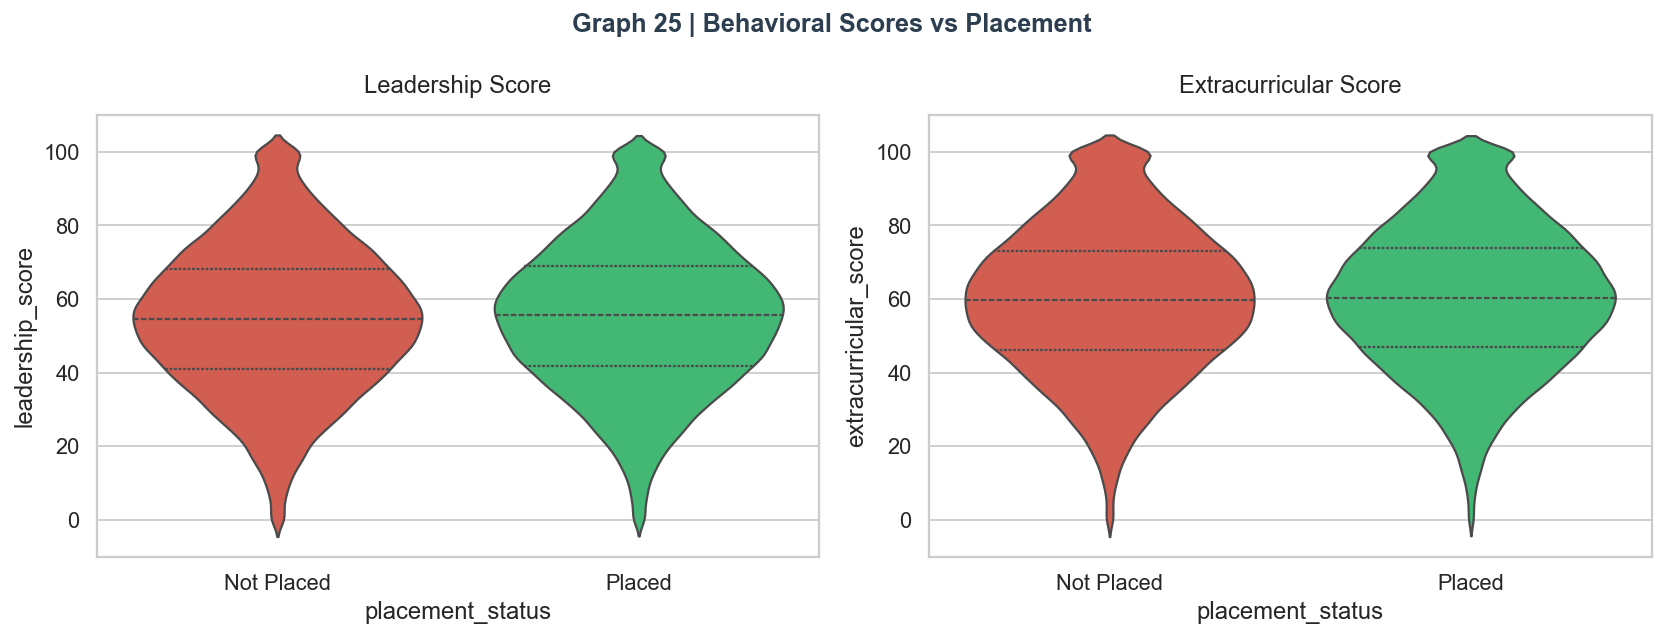

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.violinplot(data=df_clean, x="placement_status", y="leadership_score",
               palette=PALETTE, ax=axes[0], inner="quartile")
axes[0].set_title("Leadership Score")
sns.violinplot(data=df_clean, x="placement_status", y="extracurricular_score",
               palette=PALETTE, ax=axes[1], inner="quartile")
axes[1].set_title("Extracurricular Score")
fig.suptitle("Graph 25 | Behavioral Scores vs Placement", fontsize=14, fontweight="bold", color=C_DARK)
savefig("25_behavioral_scores")

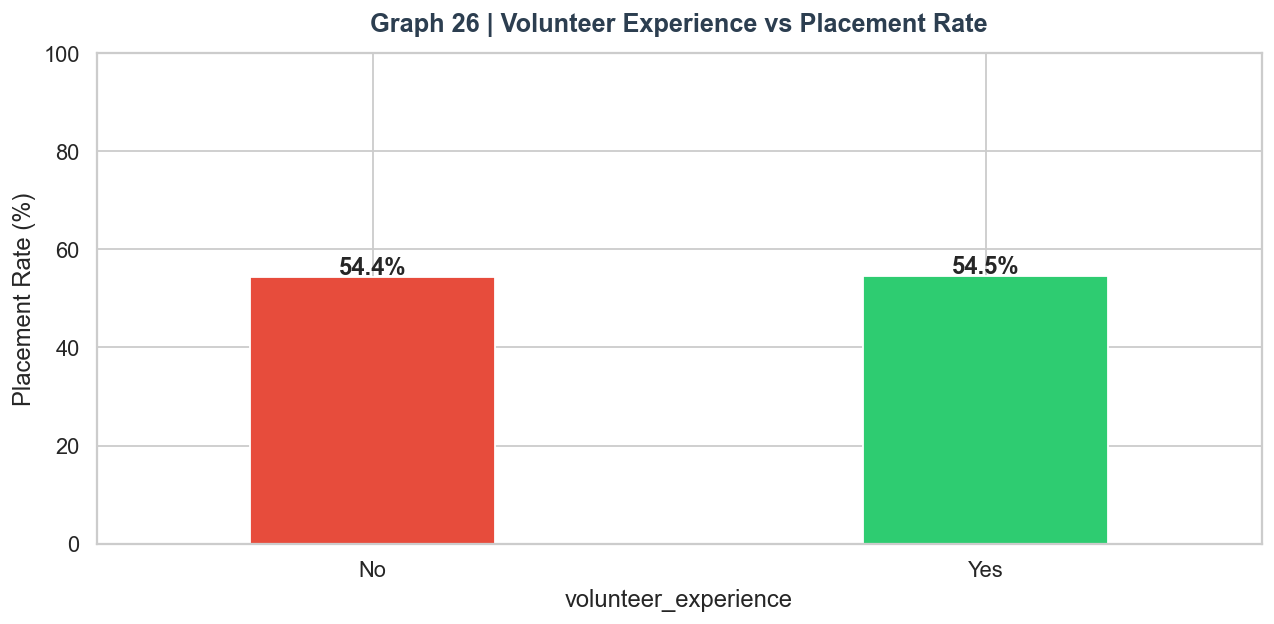

In [52]:
fig, ax = plt.subplots(figsize=(10, 5))
vol_cross = pd.crosstab(df_clean["volunteer_experience"], df_clean["placement_status"])
vol_pct   = vol_cross.div(vol_cross.sum(axis=1), axis=0) * 100
vol_pct["Placed"].plot(kind="bar", ax=ax, color=[C_RED, C_GREEN],
                       edgecolor="white", rot=0, width=0.4)
for i, v in enumerate(vol_pct["Placed"]):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")
ax.set_ylabel("Placement Rate (%)"); ax.set_ylim(0, 100)
ax.set_title("Graph 26 | Volunteer Experience vs Placement Rate", fontsize=14, fontweight="bold", color=C_DARK)
savefig("26_volunteer_placement")

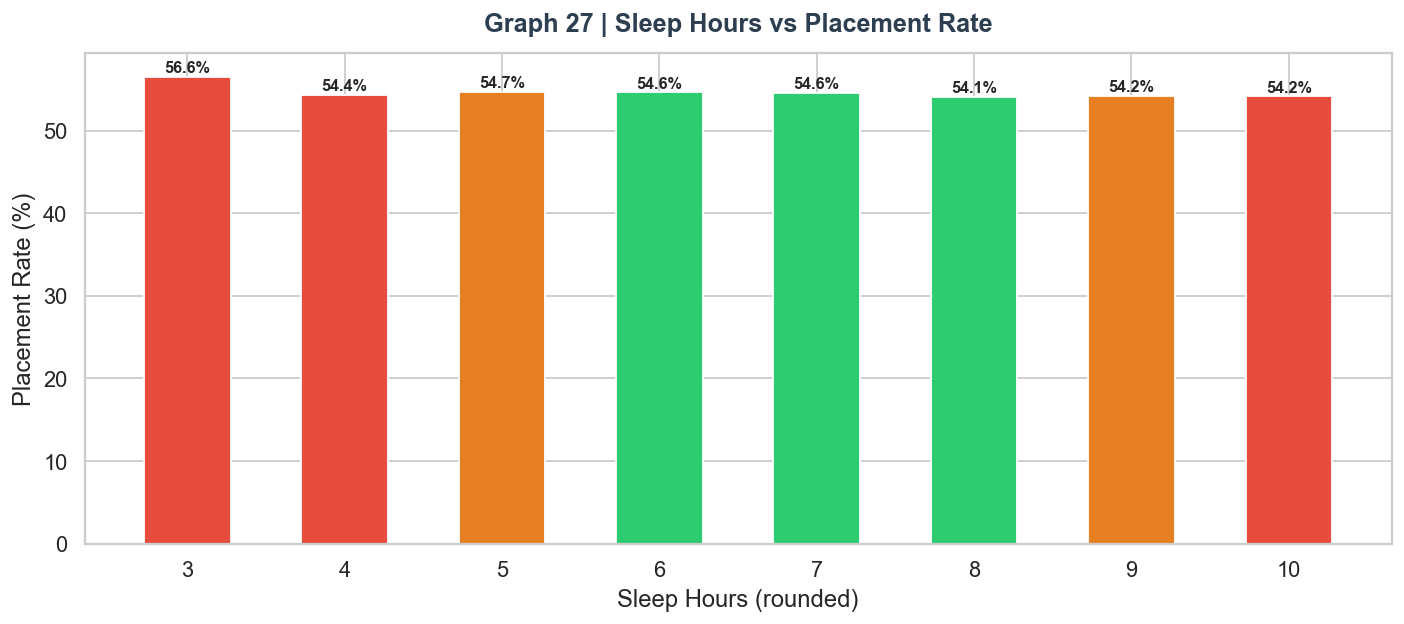

In [53]:
fig, ax = plt.subplots(figsize=(11, 5))
sleep_rate = df_clean.groupby(df_clean["sleep_hours"].round())["target"].mean() * 100
ax.bar(sleep_rate.index, sleep_rate.values,
       color=[C_GREEN if 6<=h<=8 else C_ORANGE if 5<=h<6 or 8<h<=9 else C_RED
              for h in sleep_rate.index],
       edgecolor="white", width=0.55)
for h, v in zip(sleep_rate.index, sleep_rate.values):
    ax.text(h, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax.set_xlabel("Sleep Hours (rounded)"); ax.set_ylabel("Placement Rate (%)")
ax.set_title("Graph 27 | Sleep Hours vs Placement Rate", fontsize=14, fontweight="bold", color=C_DARK)
savefig("27_sleep_placement")

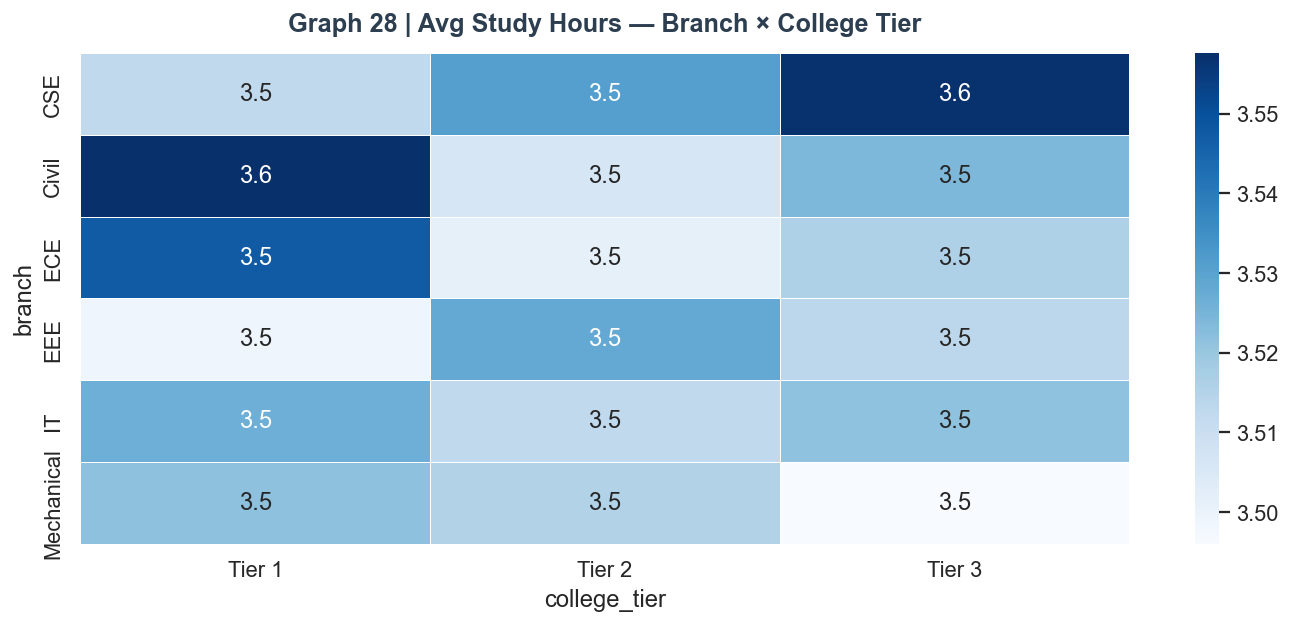

In [54]:
fig, ax = plt.subplots(figsize=(11, 5))
pivot = df_clean.pivot_table(values="study_hours_per_day",
                             index="branch", columns="college_tier", aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Blues", ax=ax, linewidths=0.5)
ax.set_title("Graph 28 | Avg Study Hours — Branch × College Tier", fontsize=14, fontweight="bold", color=C_DARK)
savefig("28_study_heatmap")

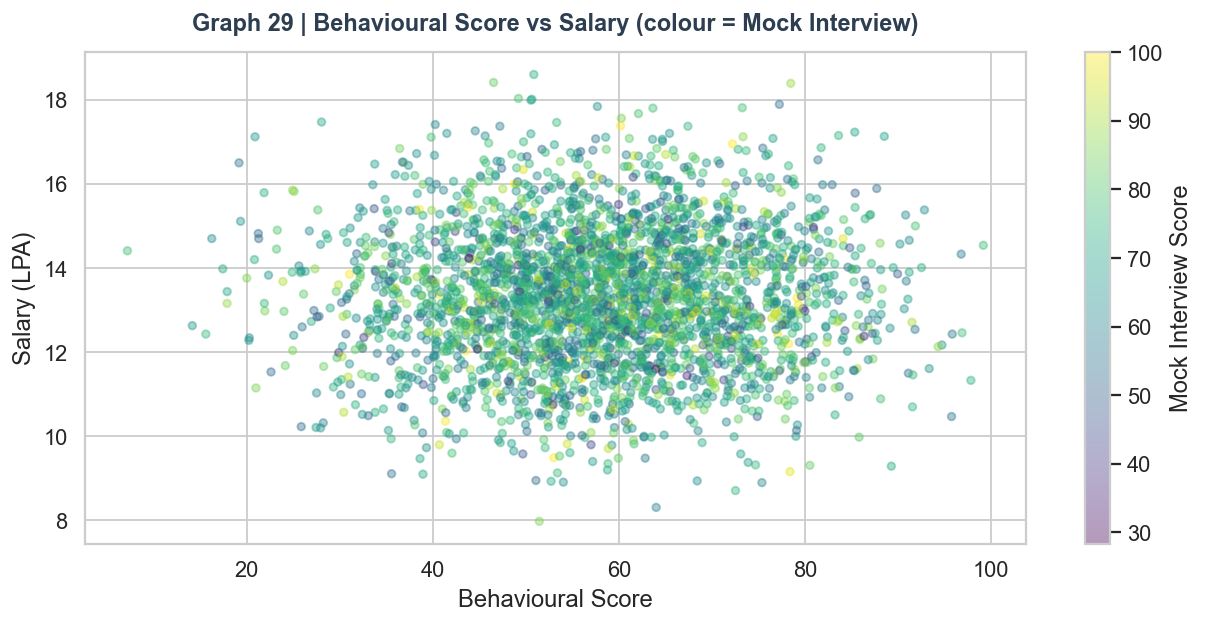

In [55]:
fig, ax = plt.subplots(figsize=(10, 5))
df_clean["behavioral_score"] = (df_clean["leadership_score"] + df_clean["extracurricular_score"]) / 2
placed_b = df_clean[df_clean["placement_status"]=="Placed"].sample(3000, random_state=2)
sc = ax.scatter(placed_b["behavioral_score"], placed_b["salary_package_lpa"],
                c=placed_b["mock_interview_score"], cmap="viridis", alpha=0.4, s=18)
plt.colorbar(sc, ax=ax, label="Mock Interview Score")
ax.set_xlabel("Behavioural Score"); ax.set_ylabel("Salary (LPA)")
ax.set_title("Graph 29 | Behavioural Score vs Salary (colour = Mock Interview)", fontsize=13, fontweight="bold", color=C_DARK)
savefig("29_behavioral_salary")

In [56]:
print("[EDA] Generating Category 6: Correlation Analysis")

[EDA] Generating Category 6: Correlation Analysis


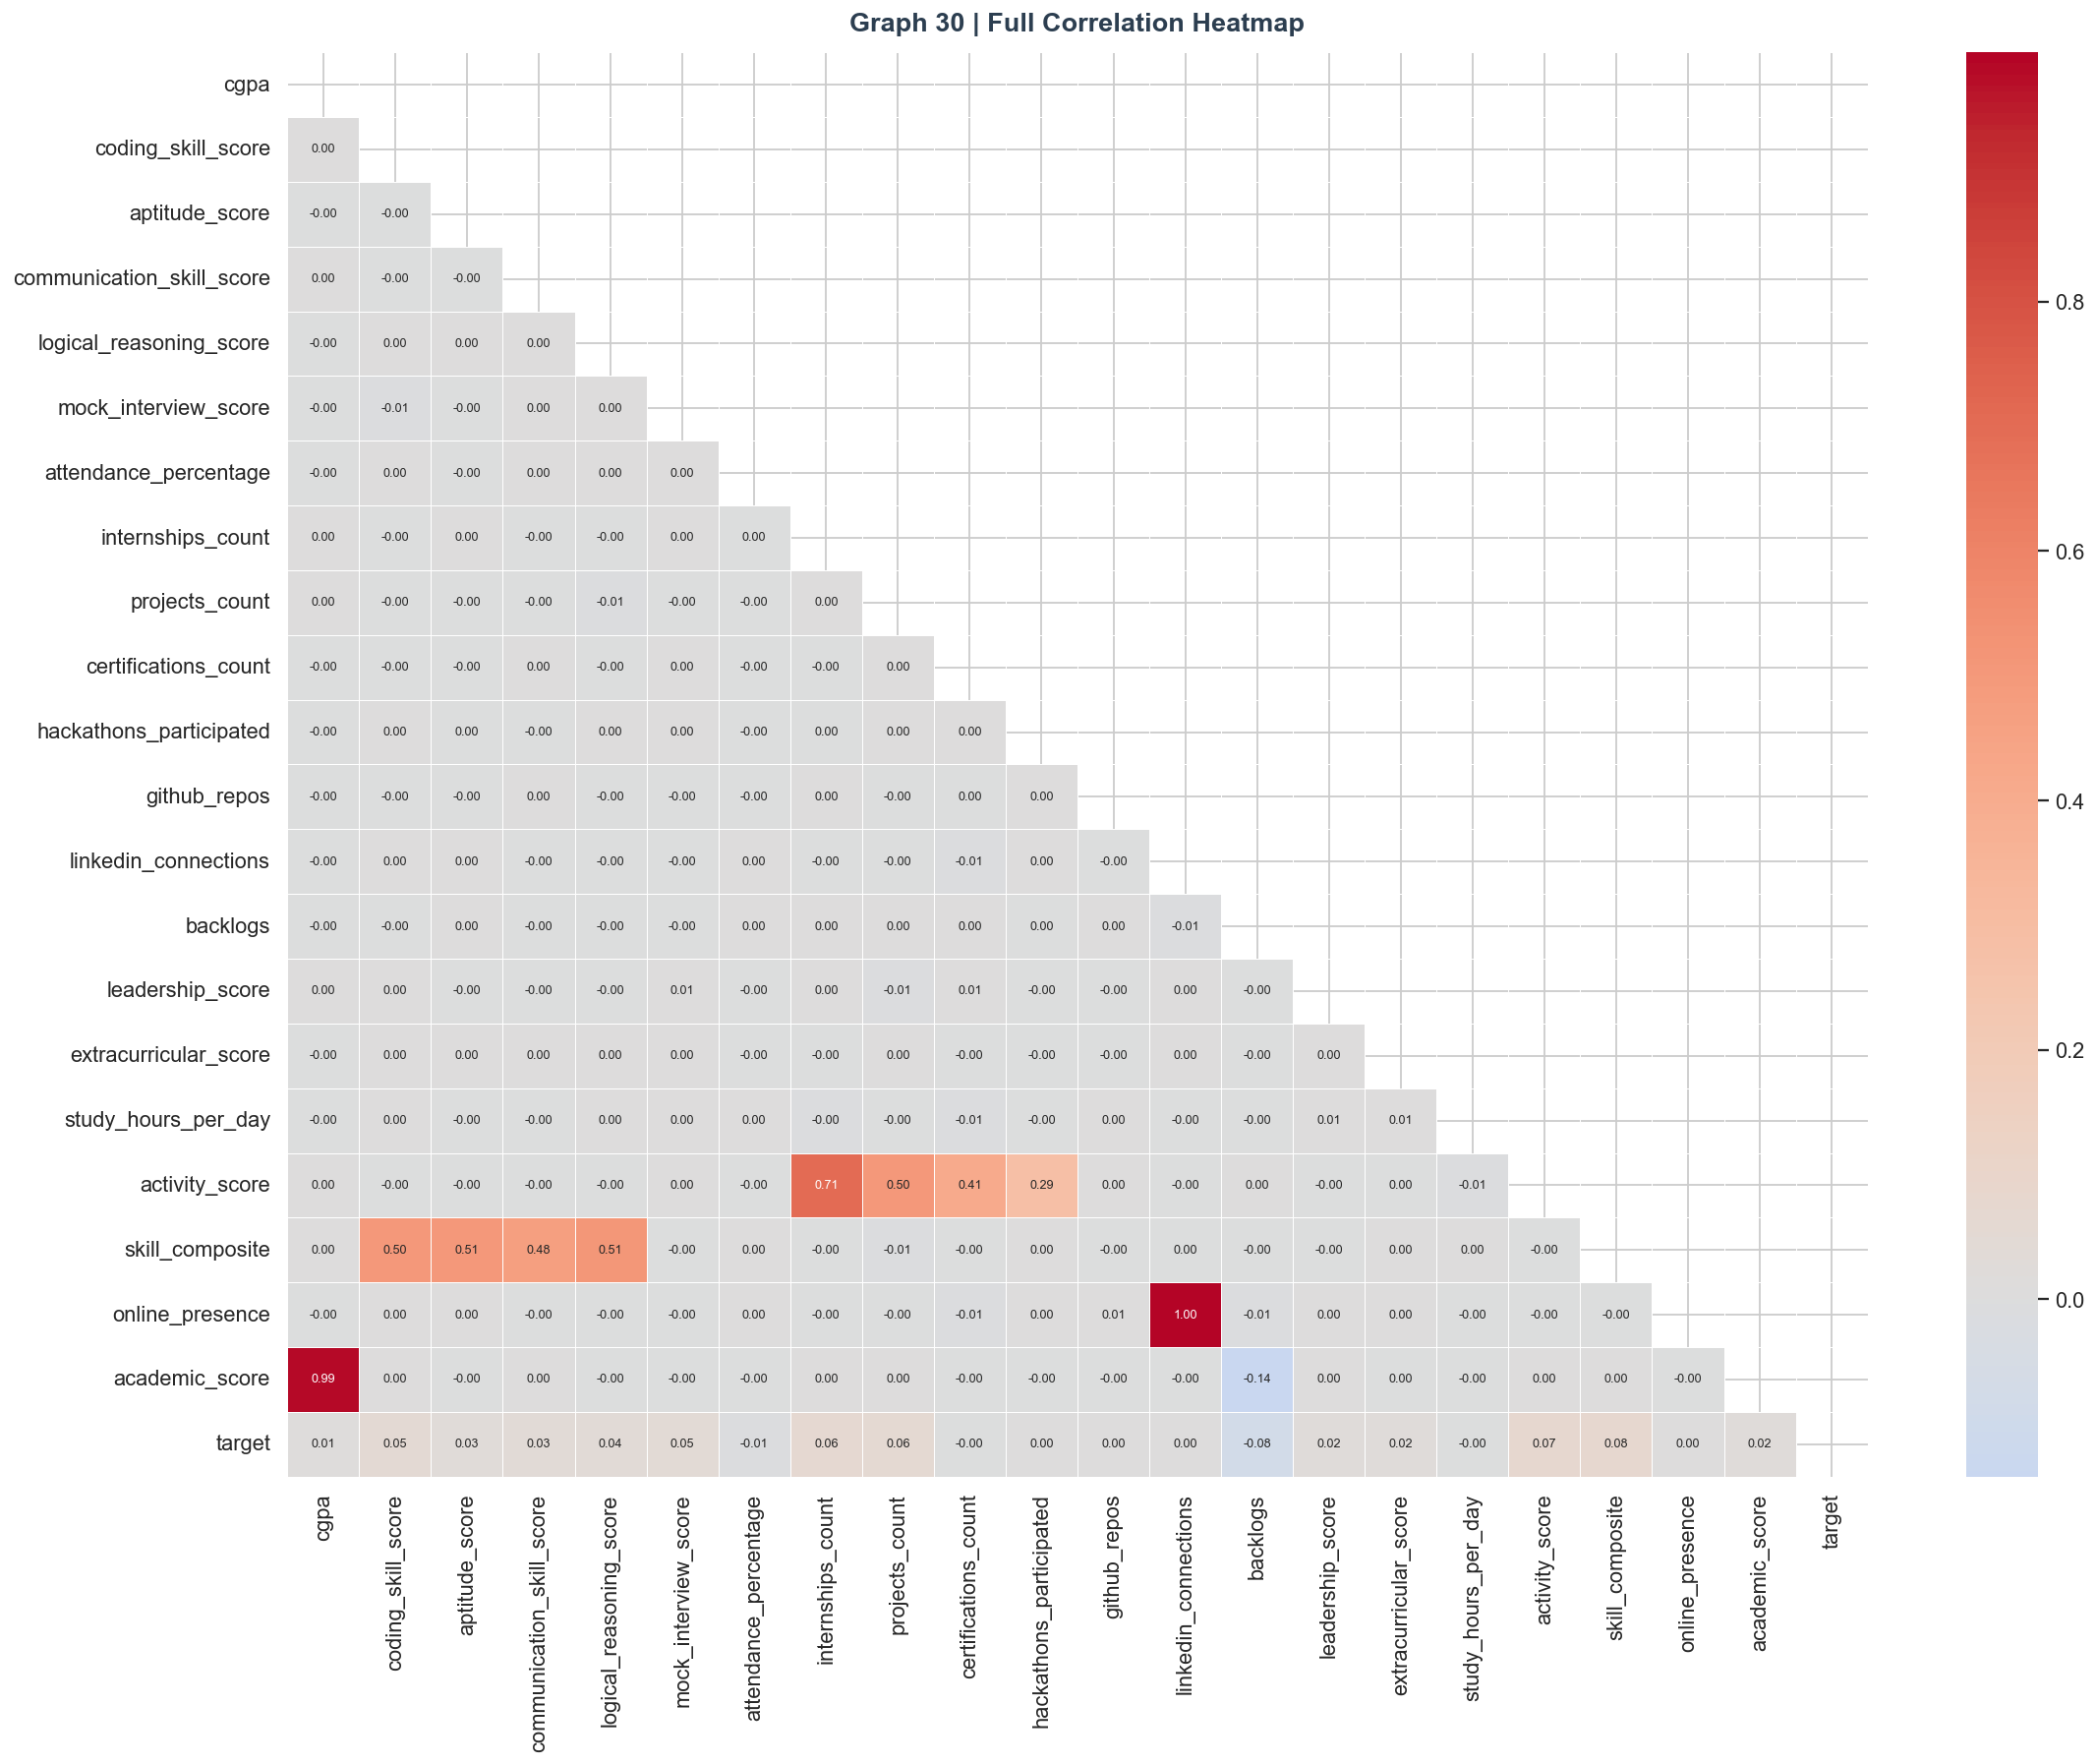

In [57]:
num_cols = ["cgpa","coding_skill_score","aptitude_score","communication_skill_score",
            "logical_reasoning_score","mock_interview_score","attendance_percentage",
            "internships_count","projects_count","certifications_count","hackathons_participated",
            "github_repos","linkedin_connections","backlogs","leadership_score",
            "extracurricular_score","study_hours_per_day","activity_score",
            "skill_composite","online_presence","academic_score","target"]
corr = df_clean[num_cols].corr()
fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.4, ax=ax, annot_kws={"size":7})
ax.set_title("Graph 30 | Full Correlation Heatmap", fontsize=15, fontweight="bold", color=C_DARK)
savefig("30_full_correlation")

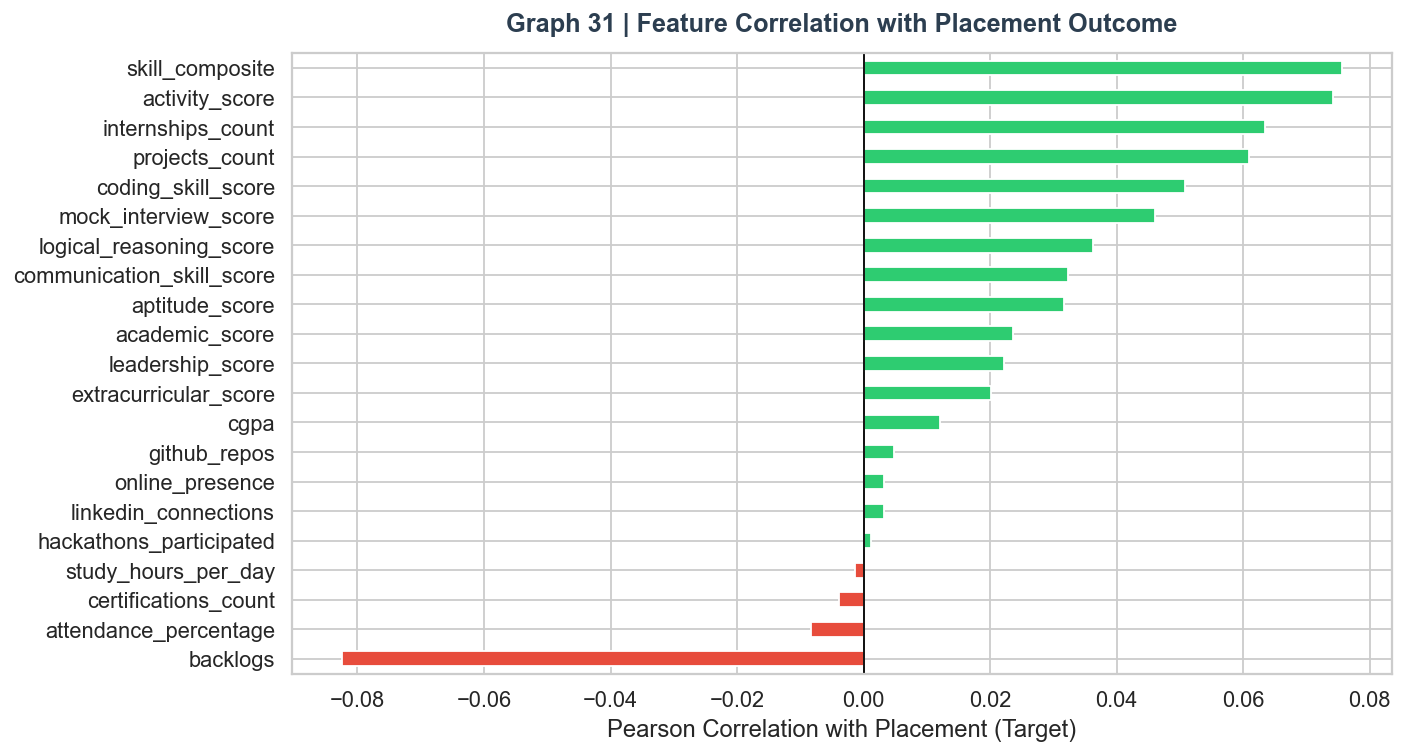

In [58]:
fig, ax = plt.subplots(figsize=(11, 6))
target_corr = corr["target"].drop("target").sort_values()
colors = [C_GREEN if v > 0 else C_RED for v in target_corr.values]
target_corr.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Pearson Correlation with Placement (Target)")
ax.set_title("Graph 31 | Feature Correlation with Placement Outcome", fontsize=14, fontweight="bold", color=C_DARK)
savefig("31_target_correlation")

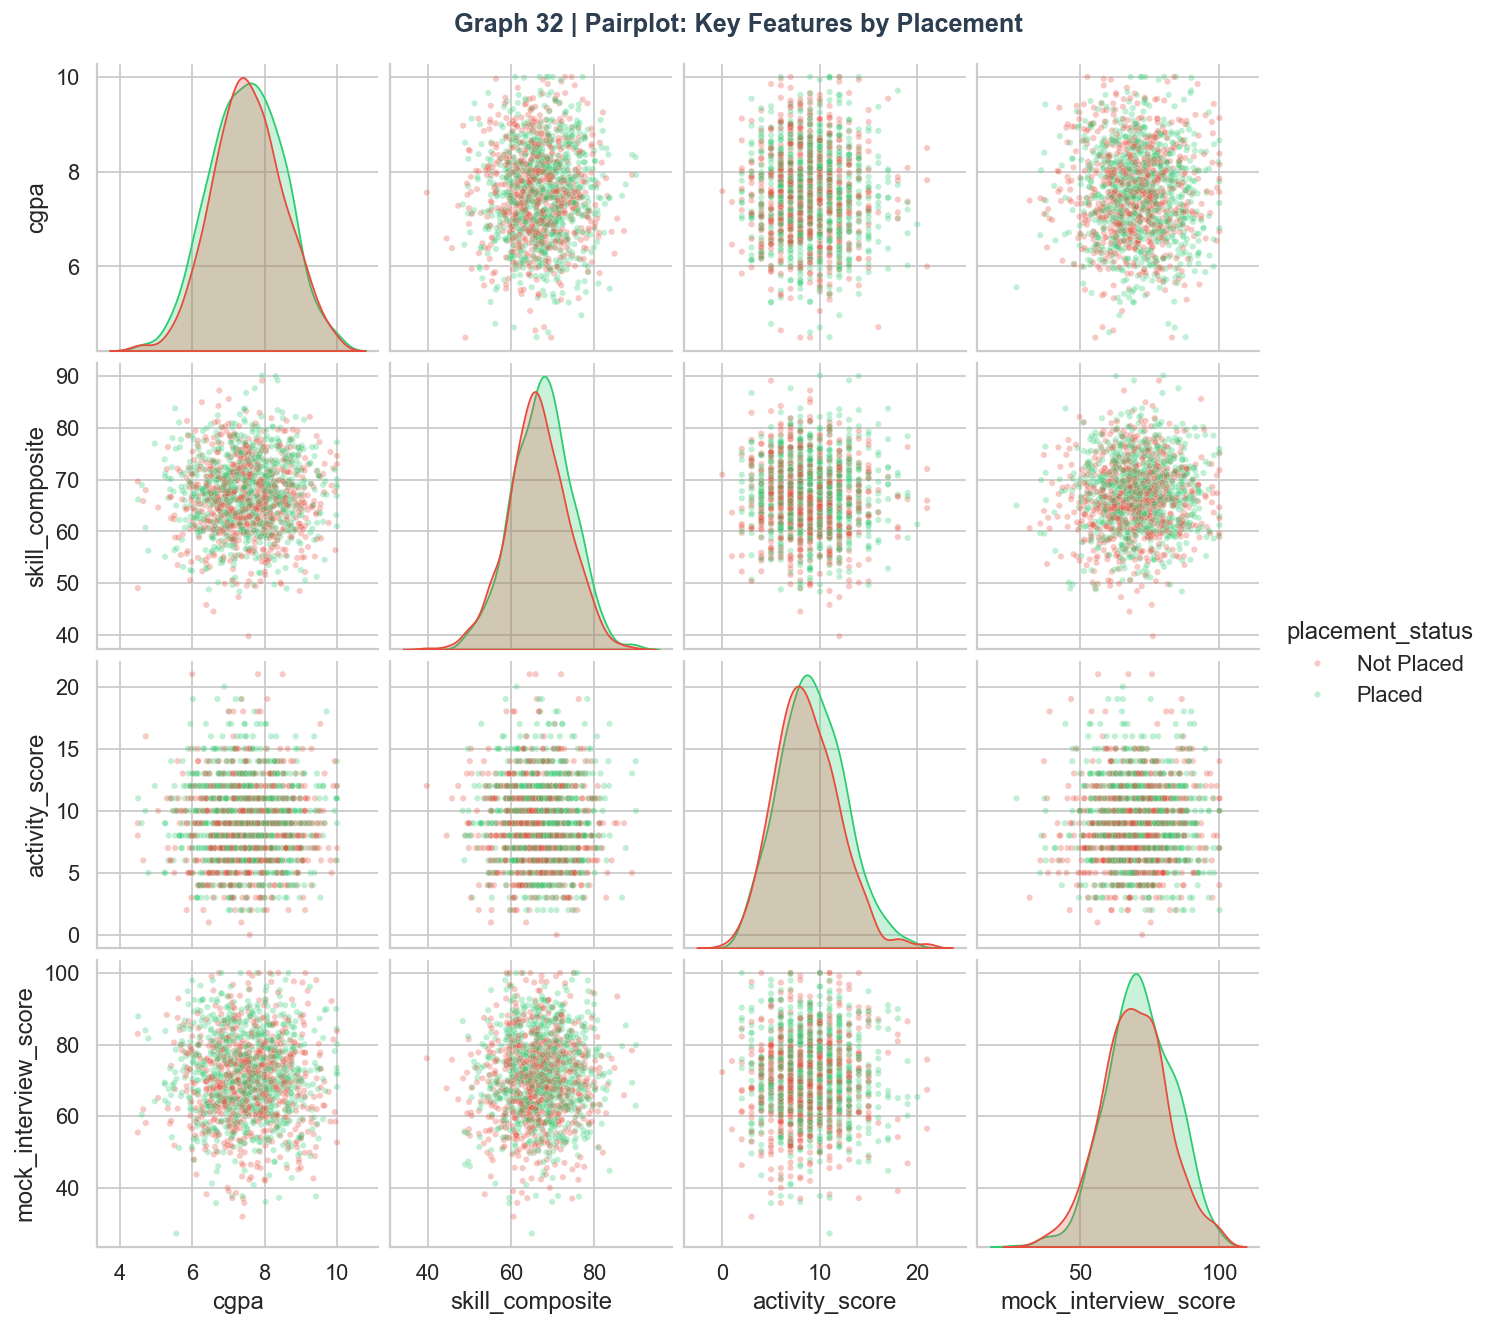

✔ Saved: 32_pairplot.png


In [60]:
pair_cols = ["cgpa","skill_composite","activity_score",
             "mock_interview_score","placement_status"]

sample_df = df_clean[pair_cols].sample(1500, random_state=99)

g = sns.pairplot(sample_df,
                 hue="placement_status",
                 palette=PALETTE,
                 plot_kws={"alpha":0.3, "s":12},
                 diag_kind="kde")

g.fig.suptitle("Graph 32 | Pairplot: Key Features by Placement",
               y=1.02,
               fontsize=14,
               fontweight="bold",
               color=C_DARK)

# ✅ SAVE
g.fig.savefig("32_pairplot.png", bbox_inches="tight")

# ✅ SHOW (IMPORTANT)
plt.show()

print("✔ Saved: 32_pairplot.png")

In [61]:
print("[EDA] Generating Category 7: Feature Interaction")

[EDA] Generating Category 7: Feature Interaction


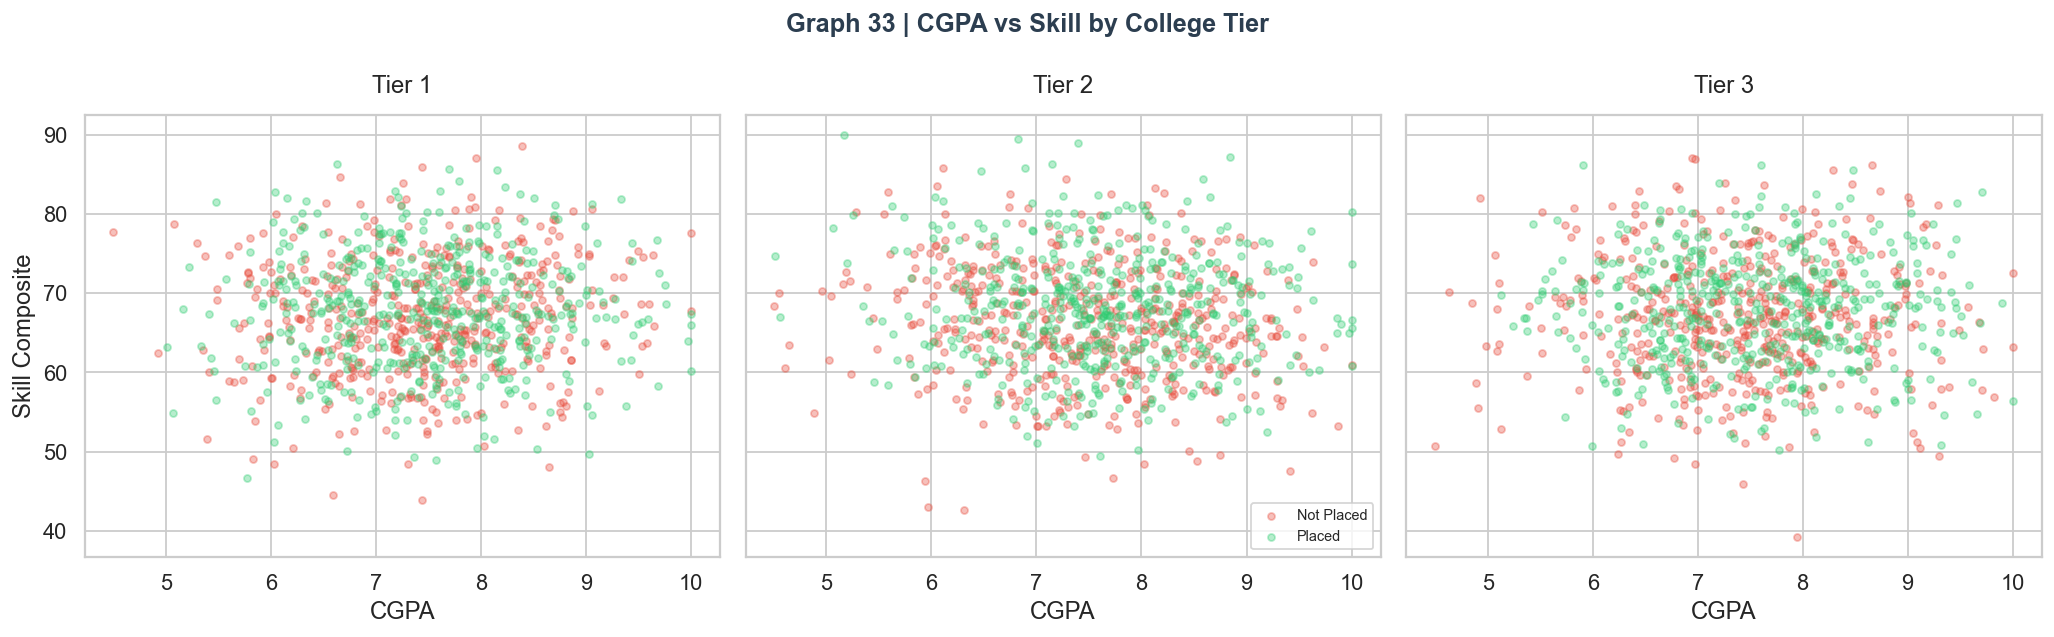

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, tier in zip(axes, ["Tier 1","Tier 2","Tier 3"]):
    sub = df_clean[df_clean["college_tier"]==tier]
    for status, color in [("Not Placed", C_RED), ("Placed", C_GREEN)]:
        s = sub[sub["placement_status"]==status].sample(min(500, len(sub)//2), random_state=7)
        ax.scatter(s["cgpa"], s["skill_composite"], c=color, alpha=0.35, s=15, label=status)
    ax.set_title(f"{tier}"); ax.set_xlabel("CGPA")
axes[0].set_ylabel("Skill Composite")
axes[1].legend(loc="lower right", fontsize=8)
fig.suptitle("Graph 33 | CGPA vs Skill by College Tier", fontsize=14, fontweight="bold", color=C_DARK)
savefig("33_cgpa_skill_tier")


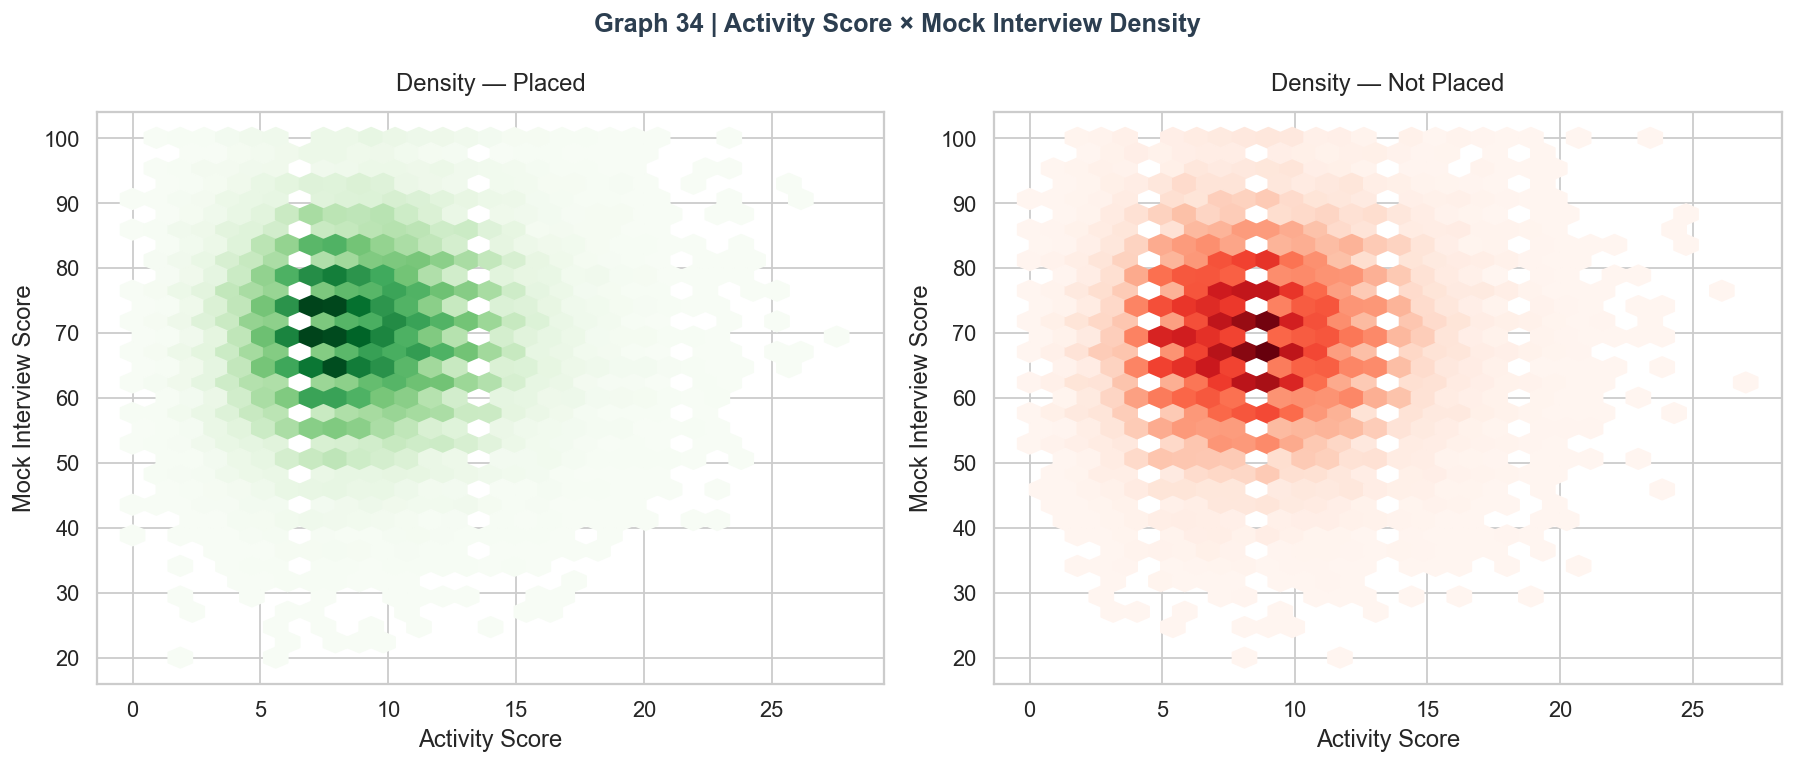

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, status, color in [(axes[0],"Placed",C_GREEN),(axes[1],"Not Placed",C_RED)]:
    s = df_clean[df_clean["placement_status"]==status]
    ax.hexbin(s["activity_score"], s["mock_interview_score"],
              gridsize=30, cmap="Greens" if color==C_GREEN else "Reds", mincnt=1)
    ax.set_xlabel("Activity Score"); ax.set_ylabel("Mock Interview Score")
    ax.set_title(f"Density — {status}")
fig.suptitle("Graph 34 | Activity Score × Mock Interview Density", fontsize=14, fontweight="bold", color=C_DARK)
savefig("34_activity_mock_density")

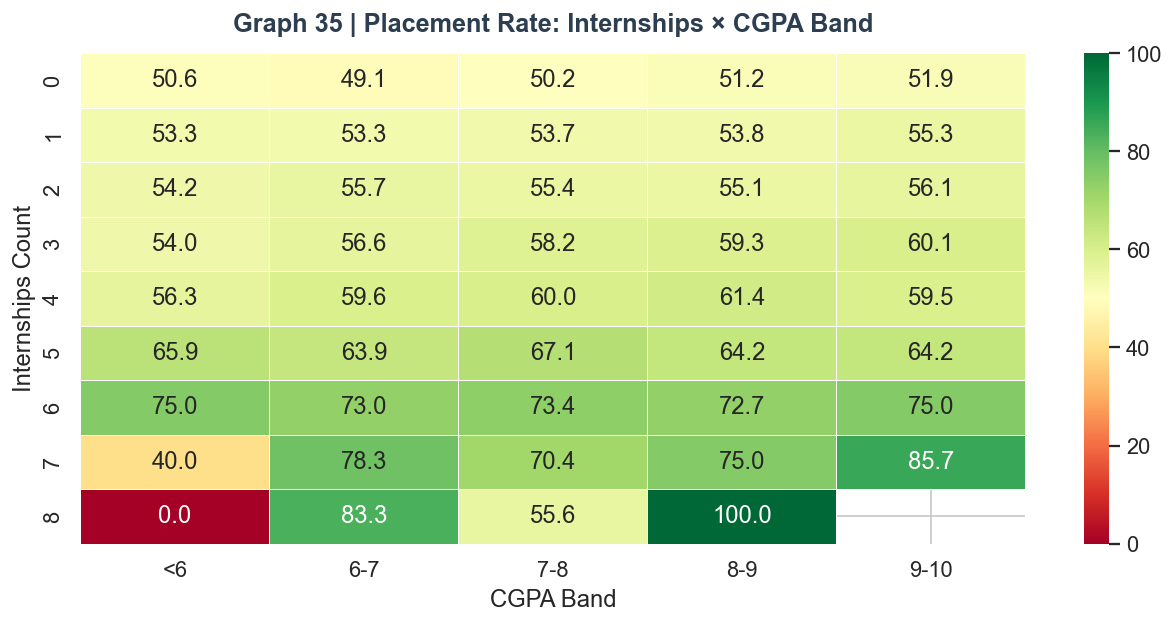

In [64]:
fig, ax = plt.subplots(figsize=(10, 5))
pivot2 = df_clean.pivot_table(values="target",
                               index="internships_count",
                               columns=pd.cut(df_clean["cgpa"],
                                             bins=[0,6,7,8,9,10],
                                             labels=["<6","6-7","7-8","8-9","9-10"]),
                               aggfunc="mean") * 100
sns.heatmap(pivot2, annot=True, fmt=".1f", cmap="RdYlGn",
            linewidths=0.5, ax=ax, vmin=0, vmax=100)
ax.set_xlabel("CGPA Band"); ax.set_ylabel("Internships Count")
ax.set_title("Graph 35 | Placement Rate: Internships × CGPA Band", fontsize=14, fontweight="bold", color=C_DARK)
savefig("35_internships_cgpa_heatmap")

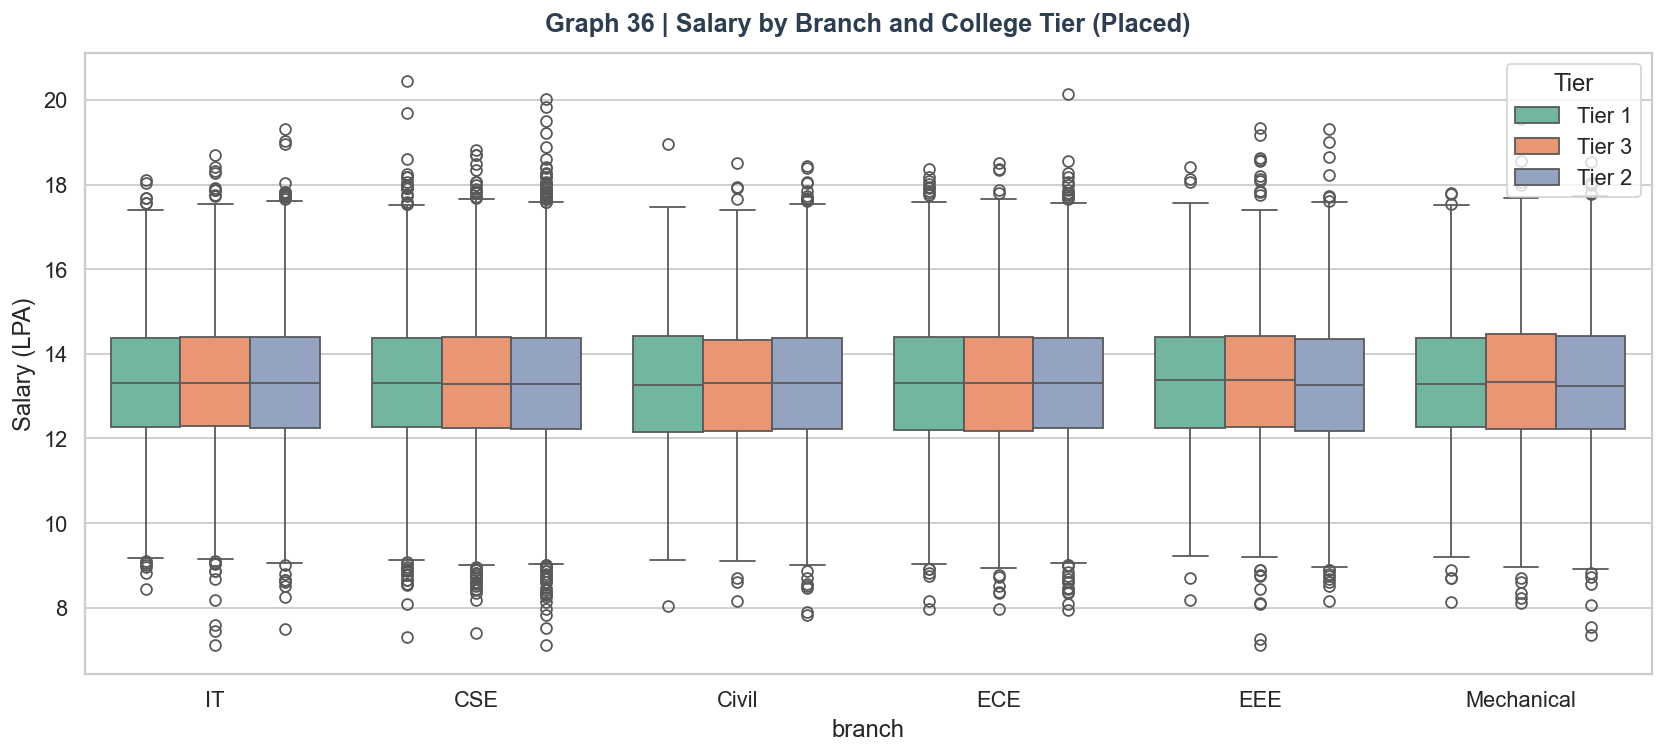

In [65]:
fig, ax = plt.subplots(figsize=(13, 6))
placed_s = df_clean[df_clean["placement_status"]=="Placed"]
sns.boxplot(data=placed_s, x="branch", y="salary_package_lpa",
            hue="college_tier", palette="Set2", ax=ax, order=branch_order)
ax.set_title("Graph 36 | Salary by Branch and College Tier (Placed)", fontsize=14, fontweight="bold", color=C_DARK)
ax.set_ylabel("Salary (LPA)"); ax.legend(title="Tier", loc="upper right")
savefig("36_salary_branch_tier")

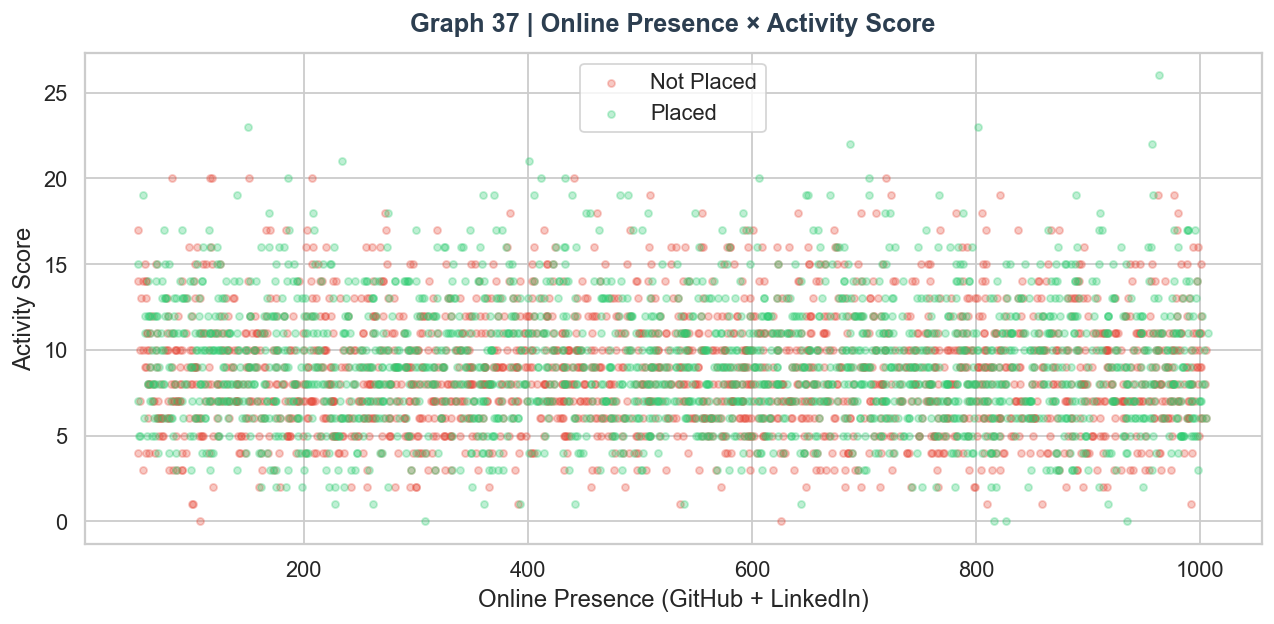

In [66]:
fig, ax = plt.subplots(figsize=(10, 5))
for status, color in [("Not Placed", C_RED), ("Placed", C_GREEN)]:
    s = df_clean[df_clean["placement_status"]==status].sample(2000, random_state=5)
    ax.scatter(s["online_presence"], s["activity_score"], c=color, alpha=0.3, s=15, label=status)
ax.set_xlabel("Online Presence (GitHub + LinkedIn)"); ax.set_ylabel("Activity Score")
ax.set_title("Graph 37 | Online Presence × Activity Score", fontsize=14, fontweight="bold", color=C_DARK)
ax.legend()
savefig("37_online_activity_scatter")

In [67]:
print("\n" + "="*60)
print("  MACHINE LEARNING — Model Building")
print("="*60)

FEATURES = ["cgpa","coding_skill_score","aptitude_score",
            "communication_skill_score","logical_reasoning_score",
            "mock_interview_score","attendance_percentage",
            "internships_count","projects_count","certifications_count",
            "hackathons_participated","github_repos","linkedin_connections",
            "backlogs","leadership_score","extracurricular_score",
            "study_hours_per_day","gender_enc","branch_enc",
            "college_tier_enc","volunteer_enc",
            "skill_composite","activity_score","online_presence","academic_score"]

X = df_clean[FEATURES]
y = df_clean["target"]   # 0 = Not Placed, 1 = Placed

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
print(f"  Train: {X_train.shape} | Test: {X_test.shape}")


  MACHINE LEARNING — Model Building
  Train: (80000, 25) | Test: (20000, 25)


In [68]:
cw = {0: 1.0, 1: (y_train==0).sum()/(y_train==1).sum()}
print(f"  Class weights: {cw}")

  Class weights: {0: 1.0, 1: np.float64(0.8362522092409392)}


In [69]:
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(class_weight=cw, max_iter=500, random_state=42))
])
pipe_dt = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    DecisionTreeClassifier(class_weight=cw, random_state=42, max_depth=10))
])
pipe_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    RandomForestClassifier(class_weight=cw, n_estimators=100, random_state=42, n_jobs=-1))
])

In [70]:
def evaluate_model(pipe, name, X_tr, y_tr, X_te, y_te):
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    y_prob = pipe.predict_proba(X_te)[:,1]
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    auc_score = auc(fpr, tpr)
    print(f"\n  ── {name} ──")
    print(f"  Accuracy : {accuracy_score(y_te, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_te, y_pred):.4f}")
    print(f"  Recall   : {recall_score(y_te, y_pred):.4f}")
    print(f"  F1-Score : {f1_score(y_te, y_pred):.4f}")
    print(f"  AUC-ROC  : {auc_score:.4f}")
    return {"name":name, "pipe":pipe, "y_pred":y_pred, "y_prob":y_prob,
            "fpr":fpr, "tpr":tpr, "auc":auc_score,
            "acc":accuracy_score(y_te,y_pred),
            "prec":precision_score(y_te,y_pred),
            "rec":recall_score(y_te,y_pred),
            "f1":f1_score(y_te,y_pred)}

results = []
results.append(evaluate_model(pipe_lr, "Logistic Regression", X_train, y_train, X_test, y_test))
results.append(evaluate_model(pipe_dt, "Decision Tree",       X_train, y_train, X_test, y_test))
results.append(evaluate_model(pipe_rf, "Random Forest",       X_train, y_train, X_test, y_test))

best = max(results, key=lambda r: r["f1"])
print(f"\n  ★ Best Model: {best['name']} (F1={best['f1']:.4f})")


  ── Logistic Regression ──
  Accuracy : 0.5590
  Precision: 0.6004
  Recall   : 0.5689
  F1-Score : 0.5842
  AUC-ROC  : 0.5856

  ── Decision Tree ──
  Accuracy : 0.5409
  Precision: 0.5771
  Recall   : 0.5875
  F1-Score : 0.5822
  AUC-ROC  : 0.5466

  ── Random Forest ──
  Accuracy : 0.5575
  Precision: 0.5738
  Recall   : 0.7281
  F1-Score : 0.6418
  AUC-ROC  : 0.5598

  ★ Best Model: Random Forest (F1=0.6418)


In [71]:
print("\n  K-Fold Cross-Validation (k=5):")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, pipe in [("Logistic Regression", pipe_lr),
                    ("Decision Tree",       pipe_dt),
                    ("Random Forest",       pipe_rf)]:
    scores = cross_val_score(pipe, X, y, cv=skf, scoring="f1", n_jobs=-1)
    print(f"  {name:22s} | F1: {scores.mean():.4f} ± {scores.std():.4f}")


  K-Fold Cross-Validation (k=5):
  Logistic Regression    | F1: 0.5844 ± 0.0044
  Decision Tree          | F1: 0.5602 ± 0.0079
  Random Forest          | F1: 0.6383 ± 0.0018


In [72]:
print("\n  GridSearchCV on Random Forest...")
param_grid = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth":    [None, 20],
    "clf__min_samples_split": [2, 5]
}
grid_rf = GridSearchCV(pipe_rf, param_grid, cv=3, scoring="f1",
                        n_jobs=-1, verbose=0)
grid_rf.fit(X_train, y_train)
print(f"  Best params  : {grid_rf.best_params_}")
print(f"  Best CV F1   : {grid_rf.best_score_:.4f}")
best_rf_pipe = grid_rf.best_estimator_


  GridSearchCV on Random Forest...
  Best params  : {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 200}
  Best CV F1   : 0.6509


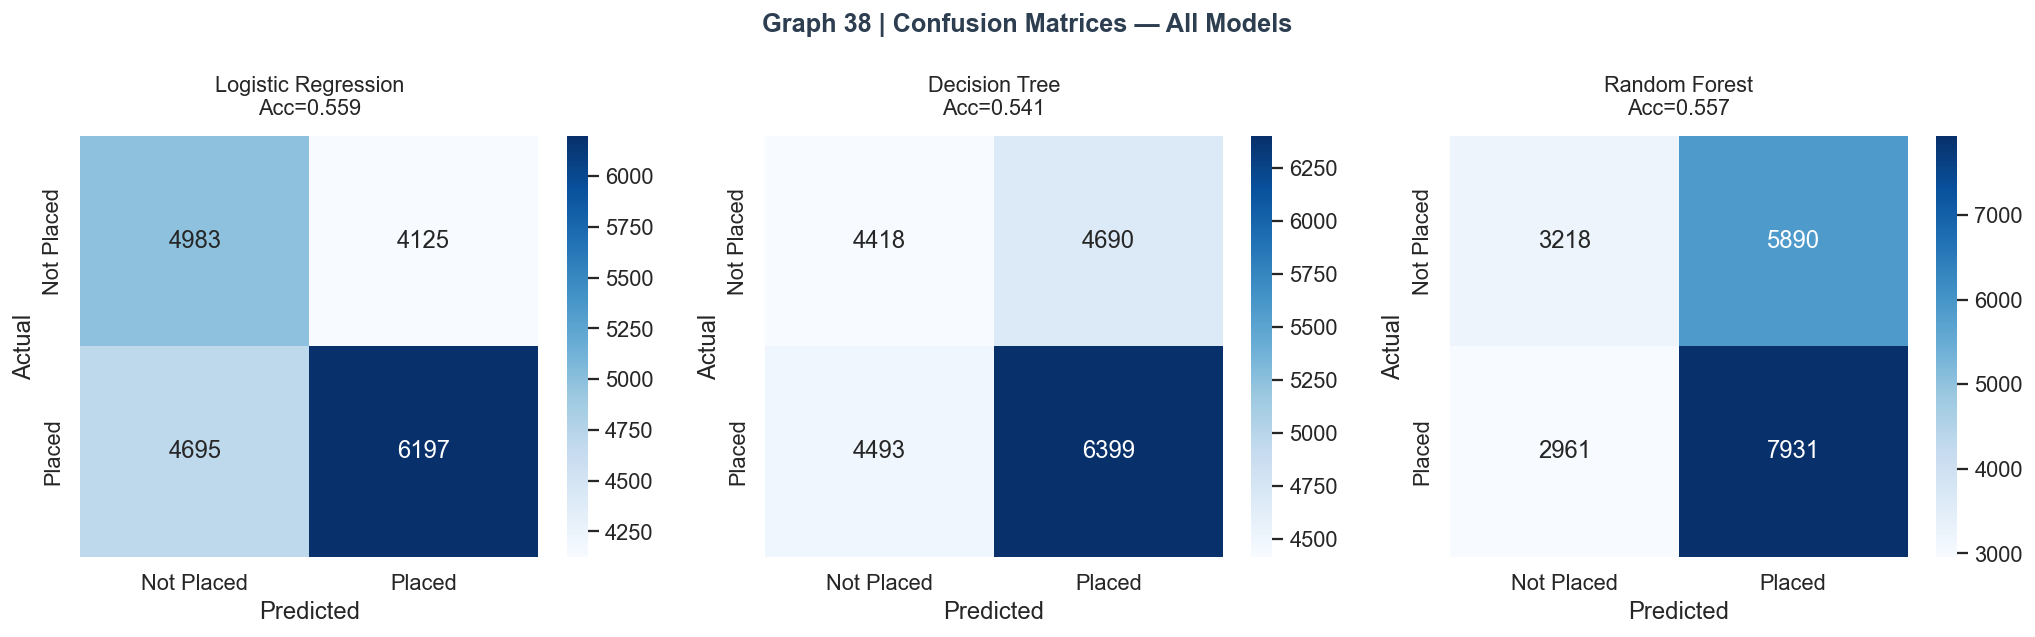

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, r in zip(axes, results):
    cm = confusion_matrix(y_test, r["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Not Placed","Placed"],
                yticklabels=["Not Placed","Placed"])
    ax.set_title(f"{r['name']}\nAcc={r['acc']:.3f}", fontsize=12)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
fig.suptitle("Graph 38 | Confusion Matrices — All Models", fontsize=14, fontweight="bold", color=C_DARK)
savefig("38_confusion_matrices")

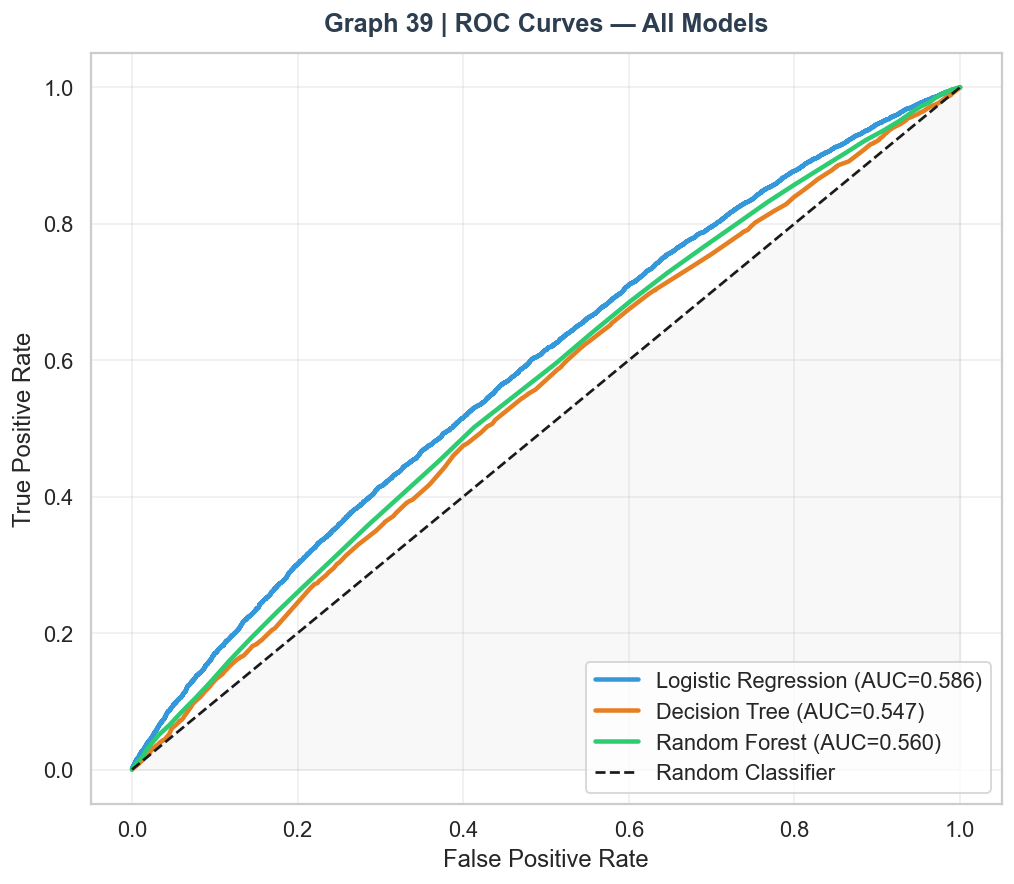

In [74]:
fig, ax = plt.subplots(figsize=(8, 7))
colors_roc = [C_BLUE, C_ORANGE, C_GREEN]
for r, c in zip(results, colors_roc):
    ax.plot(r["fpr"], r["tpr"], color=c, linewidth=2.5,
            label=f"{r['name']} (AUC={r['auc']:.3f})")
ax.plot([0,1],[0,1], "k--", linewidth=1.5, label="Random Classifier")
ax.fill_between([0,1],[0,1], alpha=0.05, color="grey")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Graph 39 | ROC Curves — All Models", fontsize=14, fontweight="bold", color=C_DARK)
ax.legend(loc="lower right"); ax.grid(True, alpha=0.3)
savefig("39_roc_curves")

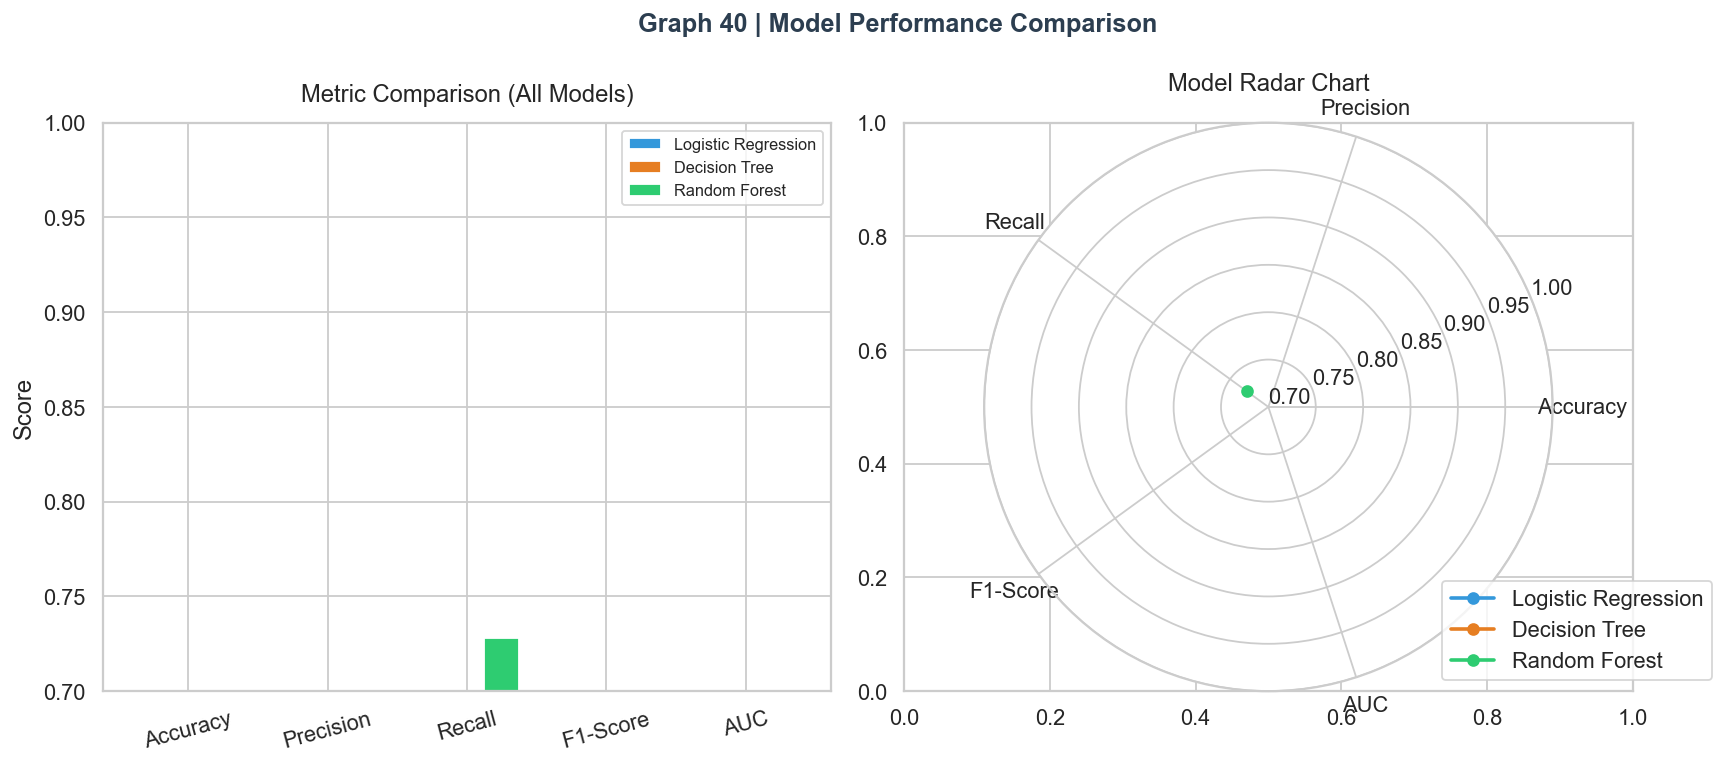

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
metrics = ["acc","prec","rec","f1","auc"]
metric_labels = ["Accuracy","Precision","Recall","F1-Score","AUC"]
model_names = [r["name"] for r in results]
x = np.arange(len(metrics)); width = 0.25
model_colors = [C_BLUE, C_ORANGE, C_GREEN]
for i, (r, c) in enumerate(zip(results, model_colors)):
    vals = [r[m] for m in metrics]
    axes[0].bar(x + i*width, vals, width, label=r["name"], color=c, edgecolor="white")
axes[0].set_xticks(x + width); axes[0].set_xticklabels(metric_labels, rotation=15)
axes[0].set_ylim(0.7, 1.0); axes[0].legend(fontsize=9)
axes[0].set_title("Metric Comparison (All Models)")
axes[0].set_ylabel("Score")
# Radar comparison
N2 = len(metrics); angles2 = np.linspace(0, 2*np.pi, N2, endpoint=False).tolist(); angles2 += angles2[:1]
ax2 = plt.subplot(122, polar=True)
for r, c in zip(results, model_colors):
    vals2 = [r[m] for m in metrics] + [r[metrics[0]]]
    ax2.plot(angles2, vals2, "o-", color=c, linewidth=2, label=r["name"])
    ax2.fill(angles2, vals2, alpha=0.08, color=c)
ax2.set_thetagrids(np.degrees(angles2[:-1]), metric_labels)
ax2.set_ylim(0.7, 1.0); ax2.legend(loc="lower right", bbox_to_anchor=(1.3, 0))
ax2.set_title("Model Radar Chart", pad=18)
fig.suptitle("Graph 40 | Model Performance Comparison", fontsize=14, fontweight="bold", color=C_DARK)
savefig("40_model_comparison")

[Graphs] Feature Importance


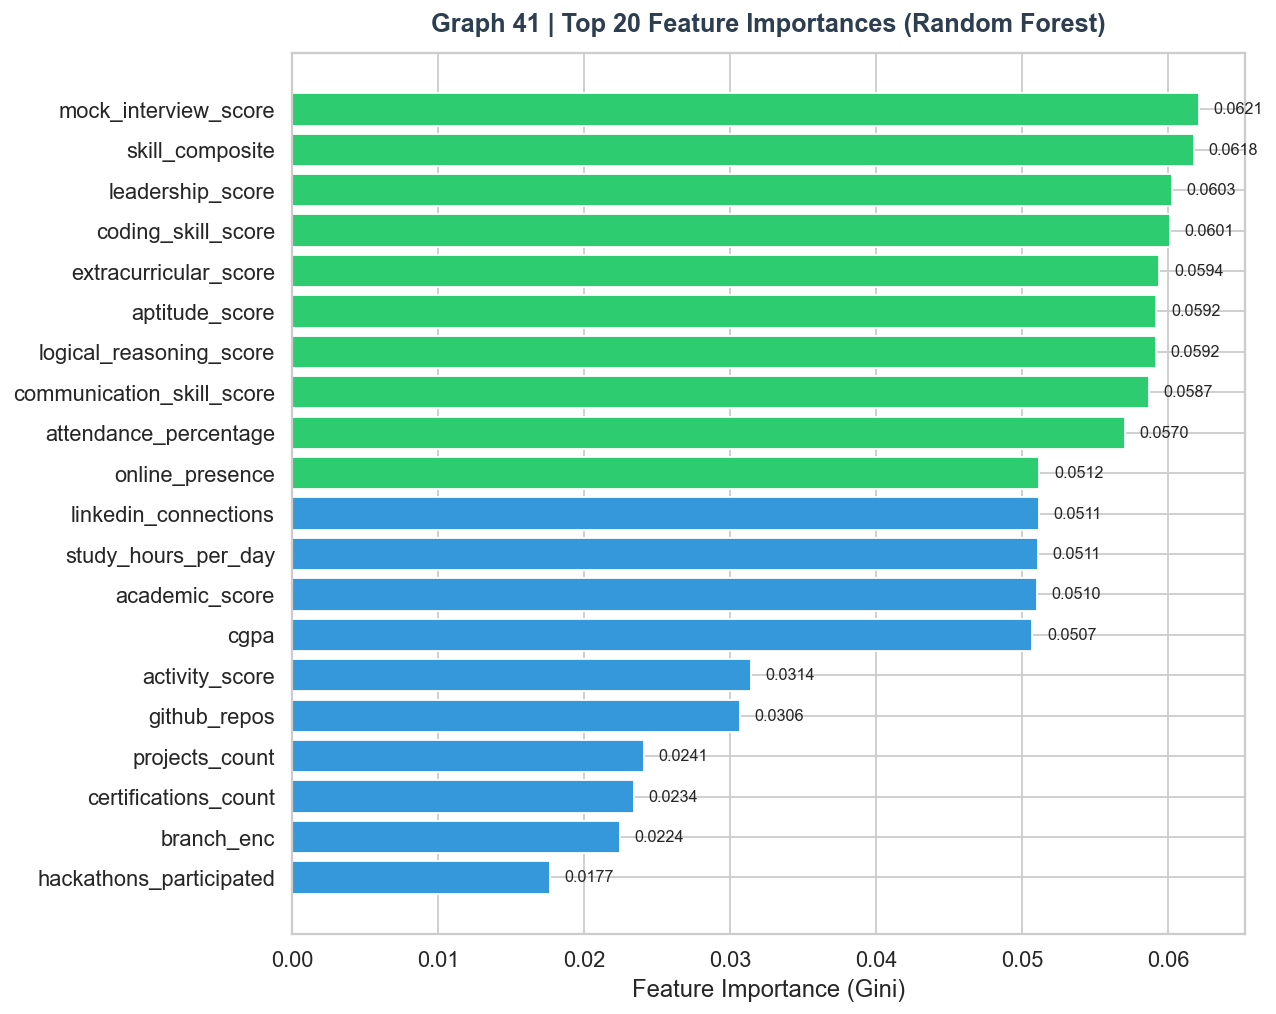

In [76]:
print("[Graphs] Feature Importance")
rf_clf = best_rf_pipe.named_steps["clf"]
importances = rf_clf.feature_importances_
fi_df = pd.DataFrame({"Feature": FEATURES, "Importance": importances}).sort_values("Importance", ascending=True).tail(20)
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(fi_df["Feature"], fi_df["Importance"],
               color=[C_GREEN if v > fi_df["Importance"].median() else C_BLUE for v in fi_df["Importance"]],
               edgecolor="white")
ax.set_xlabel("Feature Importance (Gini)"); ax.set_title("Graph 41 | Top 20 Feature Importances (Random Forest)",
                                                          fontsize=14, fontweight="bold", color=C_DARK)
for bar, val in zip(bars, fi_df["Importance"]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)
savefig("41_feature_importance")

[Graphs] Classification Report Heatmap


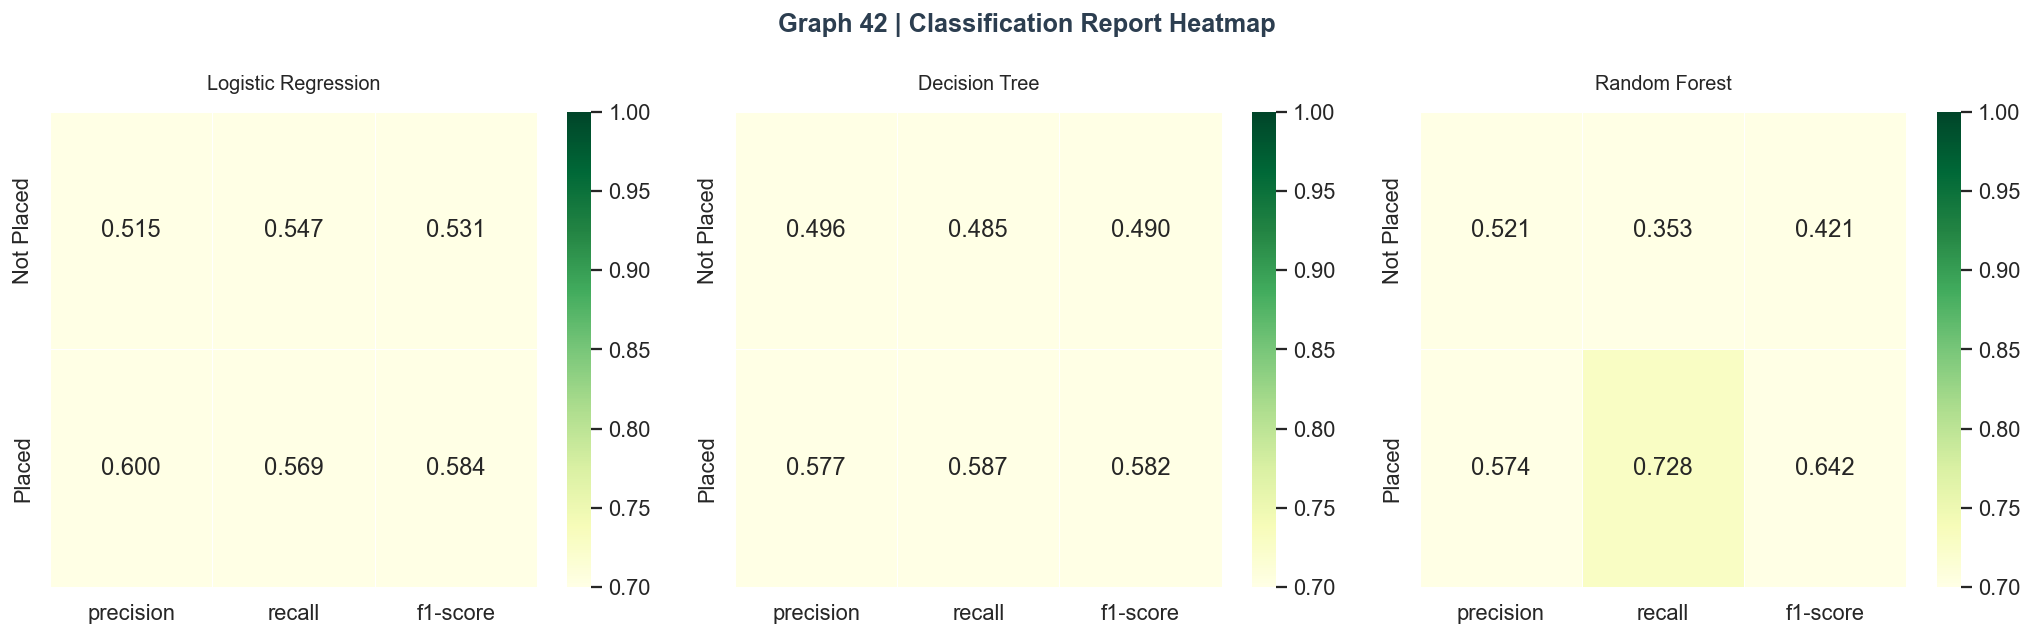

In [77]:
print("[Graphs] Classification Report Heatmap")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, r in zip(axes, results):
    from sklearn.metrics import classification_report
    report = classification_report(y_test, r["y_pred"],
                                   target_names=["Not Placed","Placed"], output_dict=True)
    rep_df = pd.DataFrame(report).T.iloc[:2, :3]
    sns.heatmap(rep_df, annot=True, fmt=".3f", cmap="YlGn", ax=ax,
                linewidths=0.5, vmin=0.7, vmax=1.0)
    ax.set_title(f"{r['name']}", fontsize=11)
fig.suptitle("Graph 42 | Classification Report Heatmap", fontsize=14, fontweight="bold", color=C_DARK)
savefig("42_classification_report_heatmap")

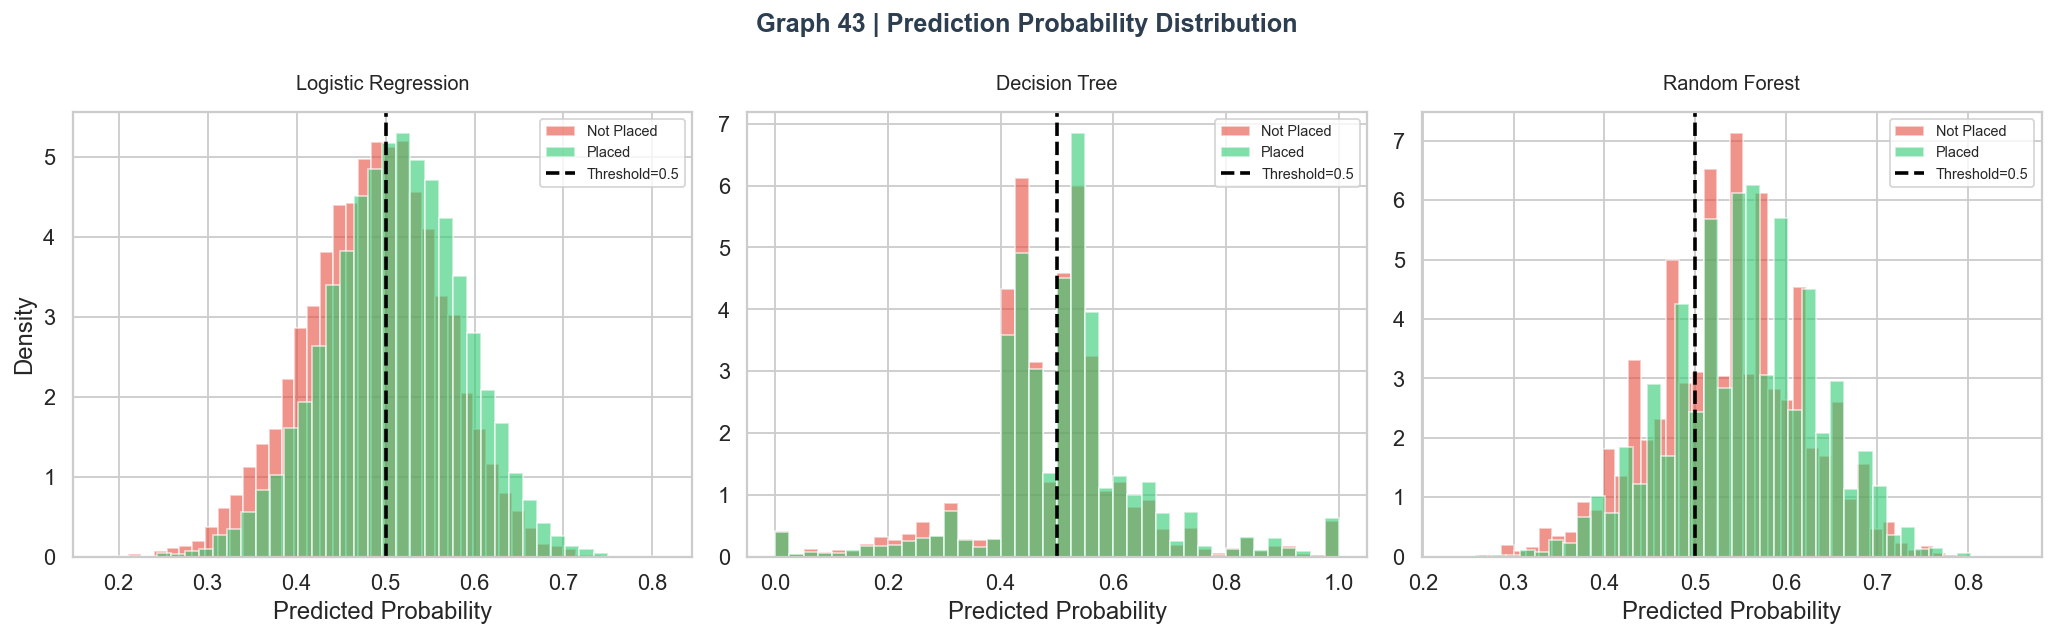

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, r in zip(axes, results):
    ax.hist(r["y_prob"][y_test==0], bins=40, alpha=0.6, color=C_RED,  label="Not Placed", density=True)
    ax.hist(r["y_prob"][y_test==1], bins=40, alpha=0.6, color=C_GREEN, label="Placed",     density=True)
    ax.axvline(0.5, color="black", linewidth=2, linestyle="--", label="Threshold=0.5")
    ax.set_xlabel("Predicted Probability"); ax.set_title(r["name"], fontsize=11)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Density")
fig.suptitle("Graph 43 | Prediction Probability Distribution", fontsize=14, fontweight="bold", color=C_DARK)
savefig("43_probability_distribution")

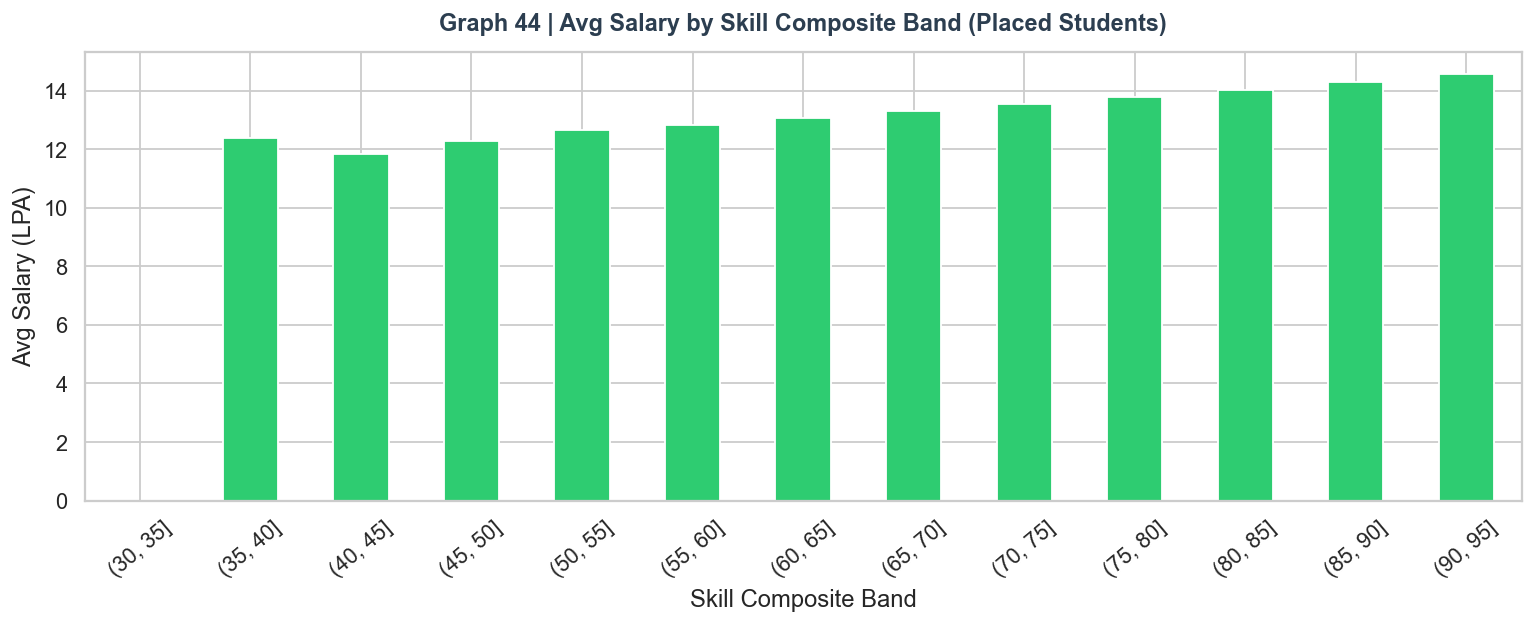

In [79]:
fig, ax = plt.subplots(figsize=(12, 5))
placed_df = df_clean[df_clean["placement_status"]=="Placed"]
sal_by_composite = placed_df.groupby(
    pd.cut(placed_df["skill_composite"], bins=np.arange(30,100,5))
)["salary_package_lpa"].mean()
sal_by_composite.plot(kind="bar", ax=ax, color=C_GREEN, edgecolor="white", rot=40)
ax.set_xlabel("Skill Composite Band"); ax.set_ylabel("Avg Salary (LPA)")
ax.set_title("Graph 44 | Avg Salary by Skill Composite Band (Placed Students)",
             fontsize=13, fontweight="bold", color=C_DARK)
savefig("44_salary_skill_band")

In [80]:
print("\n" + "="*60)
print("  FINAL PREDICTION SYSTEM — Example Student")
print("="*60)

example_student = pd.DataFrame([{
    "cgpa": 8.5,
    "coding_skill_score": 78.0,
    "aptitude_score": 74.0,
    "communication_skill_score": 72.0,
    "logical_reasoning_score": 76.0,
    "mock_interview_score": 80.0,
    "attendance_percentage": 88.0,
    "internships_count": 2,
    "projects_count": 3,
    "certifications_count": 4,
    "hackathons_participated": 2,
    "github_repos": 12,
    "linkedin_connections": 350,
    "backlogs": 0,
    "leadership_score": 72.0,
    "extracurricular_score": 68.0,
    "study_hours_per_day": 5.0,
    "gender_enc": 1,       # Male=1
    "branch_enc": 0,       # CSE mapped
    "college_tier_enc": 1, # Tier 2 mapped
    "volunteer_enc": 1,    # Yes
    "skill_composite": (78+74+72+76)/4,
    "activity_score": 2*2+3+4+2,
    "online_presence": 12+350,
    "academic_score": 8.5*10 - 0*2,
}])

prob = best_rf_pipe.predict_proba(example_student)[0][1]
pred = best_rf_pipe.predict(example_student)[0]
label = le_target.inverse_transform([pred])[0]
print(f"  Prediction     : {label}")
print(f"  Placed Prob    : {prob*100:.1f}%")
print(f"  Not-Placed Prob: {(1-prob)*100:.1f}%")


  FINAL PREDICTION SYSTEM — Example Student
  Prediction     : Placed
  Placed Prob    : 69.5%
  Not-Placed Prob: 30.5%


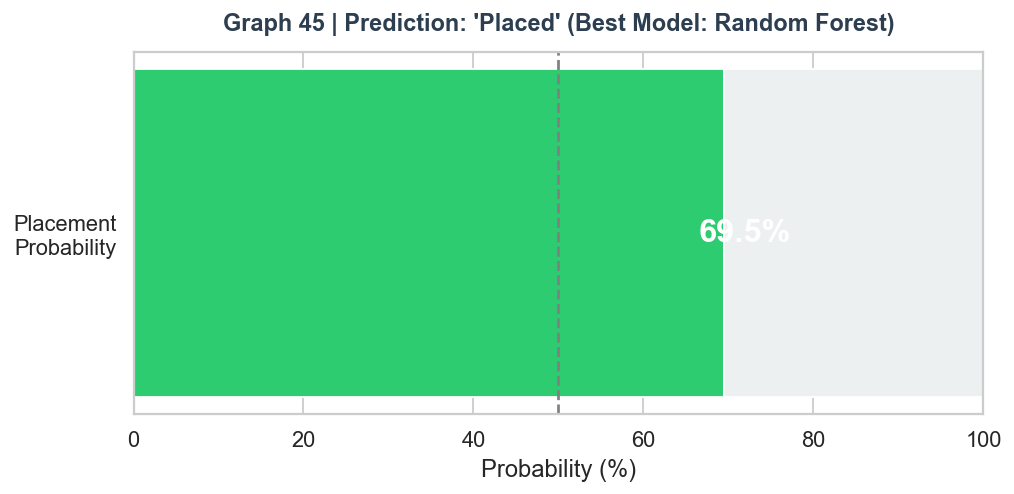

In [81]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(["Placement\nProbability"], [prob*100], color=C_GREEN if prob >= 0.5 else C_RED,
        edgecolor="white", height=0.4)
ax.barh(["Placement\nProbability"], [100 - prob*100], left=[prob*100],
        color="#ecf0f1", edgecolor="white", height=0.4)
ax.text(prob*100 - 3, 0, f"{prob*100:.1f}%", va="center", fontweight="bold",
        fontsize=18, color="white")
ax.set_xlim(0, 100)
ax.set_xlabel("Probability (%)")
ax.set_title(f"Graph 45 | Prediction: '{label}' (Best Model: {best['name']})",
             fontsize=13, fontweight="bold", color=C_DARK)
ax.axvline(50, color="grey", linestyle="--", linewidth=1.5)
savefig("45_prediction_gauge")

In [82]:
print("\n" + "="*60)
print("  FINAL MODEL COMPARISON SUMMARY")
print("="*60)
summary = pd.DataFrame([{
    "Model":     r["name"],
    "Accuracy":  f"{r['acc']:.4f}",
    "Precision": f"{r['prec']:.4f}",
    "Recall":    f"{r['rec']:.4f}",
    "F1-Score":  f"{r['f1']:.4f}",
    "AUC-ROC":   f"{r['auc']:.4f}",
} for r in results])
print(summary.to_string(index=False))
print(f"\n  ★ Best Model: {best['name']}")

print("\n  ALL GRAPHS SAVED SUCCESSFULLY TO:", OUT)
print("  Total Graphs Generated: 45")
print("="*60)


  FINAL MODEL COMPARISON SUMMARY
              Model Accuracy Precision Recall F1-Score AUC-ROC
Logistic Regression   0.5590    0.6004 0.5689   0.5842  0.5856
      Decision Tree   0.5409    0.5771 0.5875   0.5822  0.5466
      Random Forest   0.5575    0.5738 0.7281   0.6418  0.5598

  ★ Best Model: Random Forest

  ALL GRAPHS SAVED SUCCESSFULLY TO: outputs
  Total Graphs Generated: 45
